# IMC Prosperity 4 — Round 3 Data Analysis Notebook

This notebook is focused on the actual Round 3 products:

- `HYDROGEL_PACK`
- `VELVETFRUIT_EXTRACT`
- `VEV_4000` to `VEV_6500`

The goal is to understand the data deeply enough to build a profitable trading strategy:
spot fair value, microstructure, voucher pricing, implied volatility, strike-by-strike behavior, and inventory risk.

What is intentionally removed here:
- generic ML models that do not map cleanly to the round,
- unrelated conversion-arbitrage templates,
- broad pair-trading exercises that do not involve these products,
- noisy simulations that do not help with live execution.

The notebook is structured as:
1. load and clean the data
2. analyze each product family
3. price the vouchers with Black-Scholes
4. inspect trade flow and fill behavior
5. translate findings into strategy rules


## 0. Imports and configuration

Keep the analysis lightweight and reproducible. The data is already rich; the main job is to transform it into signals.


In [1]:
import json
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2
plt.rcParams["font.size"] = 11

DATA_DIR = Path("../data")
PRICES_FILES = sorted(DATA_DIR.glob("prices_round_3_day_*.csv"))
TRADES_FILES = sorted(DATA_DIR.glob("trades_round_3_day_*.csv"))

PRODUCTS = [
    "HYDROGEL_PACK",
    "VELVETFRUIT_EXTRACT",
    "VEV_4000",
    "VEV_4500",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
    "VEV_5400",
    "VEV_5500",
    "VEV_6000",
    "VEV_6500",
]

STRIKES = {f"VEV_{k}": k for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]}
POSITION_LIMITS: Dict[str, int] = {
    "HYDROGEL_PACK": 200,
    "VELVETFRUIT_EXTRACT": 200,
    **{f"VEV_{k}": 300 for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]},
}

TICKS_PER_DAY = 1_000_000
TTE_START_DAYS = 5.0
TRADING_DAYS = 252.0


## 1. Load the CSV files

The `prices_*` files are the market-book snapshots.  
The `trades_*` files are executed market trades.

Important columns in prices:
- `bid_price_1 ... bid_price_3`
- `ask_price_1 ... ask_price_3`
- `mid_price`
- `profit_and_loss`

Important columns in trades:
- `buyer`, `seller`
- `symbol`
- `price`, `quantity`


In [2]:
def load_prices_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df["day"] = df["day"].astype(int)
    df["timestamp"] = df["timestamp"].astype(int)
    df["global_time"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    return df

def load_trades_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df["timestamp"] = df["timestamp"].astype(int)
    try:
        day = int(str(path.stem).split("day_")[-1])
    except Exception:
        day = -1
    df["day"] = day
    df["global_time"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    for col in ["buyer", "seller", "symbol"]:
        if col in df.columns:
            df[col] = df[col].fillna("")
    for col in ["price", "quantity"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

prices = pd.concat([load_prices_file(p) for p in PRICES_FILES], ignore_index=True)
trades = pd.concat([load_trades_file(p) for p in TRADES_FILES], ignore_index=True)
trades_day = trades.copy()

prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]
prices["rel_spread_bps"] = prices["spread"] / prices["mid_price"] * 10_000
prices["imbalance_1"] = (
    prices["bid_volume_1"].fillna(0) - prices["ask_volume_1"].fillna(0)
) / (prices["bid_volume_1"].fillna(0) + prices["ask_volume_1"].fillna(0) + 1e-9)

print("Loaded prices:", prices.shape)
print("Loaded trades:", trades.shape)
print("Products:", sorted(prices["product"].unique()))



Loaded prices: (360000, 21)
Loaded trades: (4048, 9)
Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


## 2. Data sanity checks

Before analyzing signals, make sure the data is internally consistent:
- each product has a full time series,
- timestamps line up within a day,
- spreads are positive,
- voucher strikes show the expected price hierarchy.


In [3]:
def product_list(df: pd.DataFrame) -> List[str]:
    return sorted(df["product"].unique())

def quick_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for p in product_list(df):
        x = df[df["product"] == p].copy()
        mid = x["mid_price"].astype(float)
        ret = mid.pct_change().dropna()
        rows.append({
            "product": p,
            "rows": len(x),
            "days": x["day"].nunique(),
            "mean_mid": mid.mean(),
            "median_mid": mid.median(),
            "std_mid": mid.std(),
            "mean_spread": x["spread"].mean(),
            "mean_rel_spread_bps": x["rel_spread_bps"].mean(),
            "lag1_acf": ret.autocorr(1) if len(ret) > 5 else np.nan,
            "trade_count": int((trades["symbol"] == p).sum()) if "symbol" in trades.columns else np.nan,
        })
    return pd.DataFrame(rows)

summary_df = quick_summary(prices)
display(summary_df.round(4))


c:\Users\amans\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\amans\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


,product,rows,days,mean_mid,median_mid,std_mid,mean_spread,mean_rel_spread_bps,lag1_acf,trade_count
0,HYDROGEL_PACK,30000,3,9990.8069,9994.0,31.9352,15.7208,15.7353,-0.1292,1010
1,VELVETFRUIT_EXTRACT,30000,3,5250.0981,5249.5,15.6304,4.9881,9.5010,-0.1588,1372
2,VEV_4000,30000,3,1250.1098,1249.5,15.6472,20.8135,166.4926,-0.2844,464
3,VEV_4500,30000,3,750.1096,749.0,15.6399,15.8527,211.3411,-0.2251,1
4,VEV_5000,30000,3,255.0224,254.0,14.3756,6.0433,237.0700,-0.0996,1
5,VEV_5100,30000,3,166.8054,166.5,12.7426,4.2958,257.8870,-0.0980,1
6,VEV_5200,30000,3,95.5488,96.0,9.6642,2.8881,303.4264,-0.1349,18
7,VEV_5300,30000,3,46.7599,47.0,6.2281,2.1068,454.8305,-0.2198,121
8,VEV_5400,30000,3,15.9519,16.5,3.4292,1.3814,900.1054,-0.2500,225
9,VEV_5500,30000,3,6.6414,6.5,1.7388,1.1498,1858.6394,-0.2412,267


## 3. Price traces and spreads

The first question for each product family:
- is the price stable, trending, or regime-shifting?
- how wide is the market spread?
- is the spread stable or does it widen under stress?

This matters because market making only works when your expected edge exceeds the cost of being picked off.


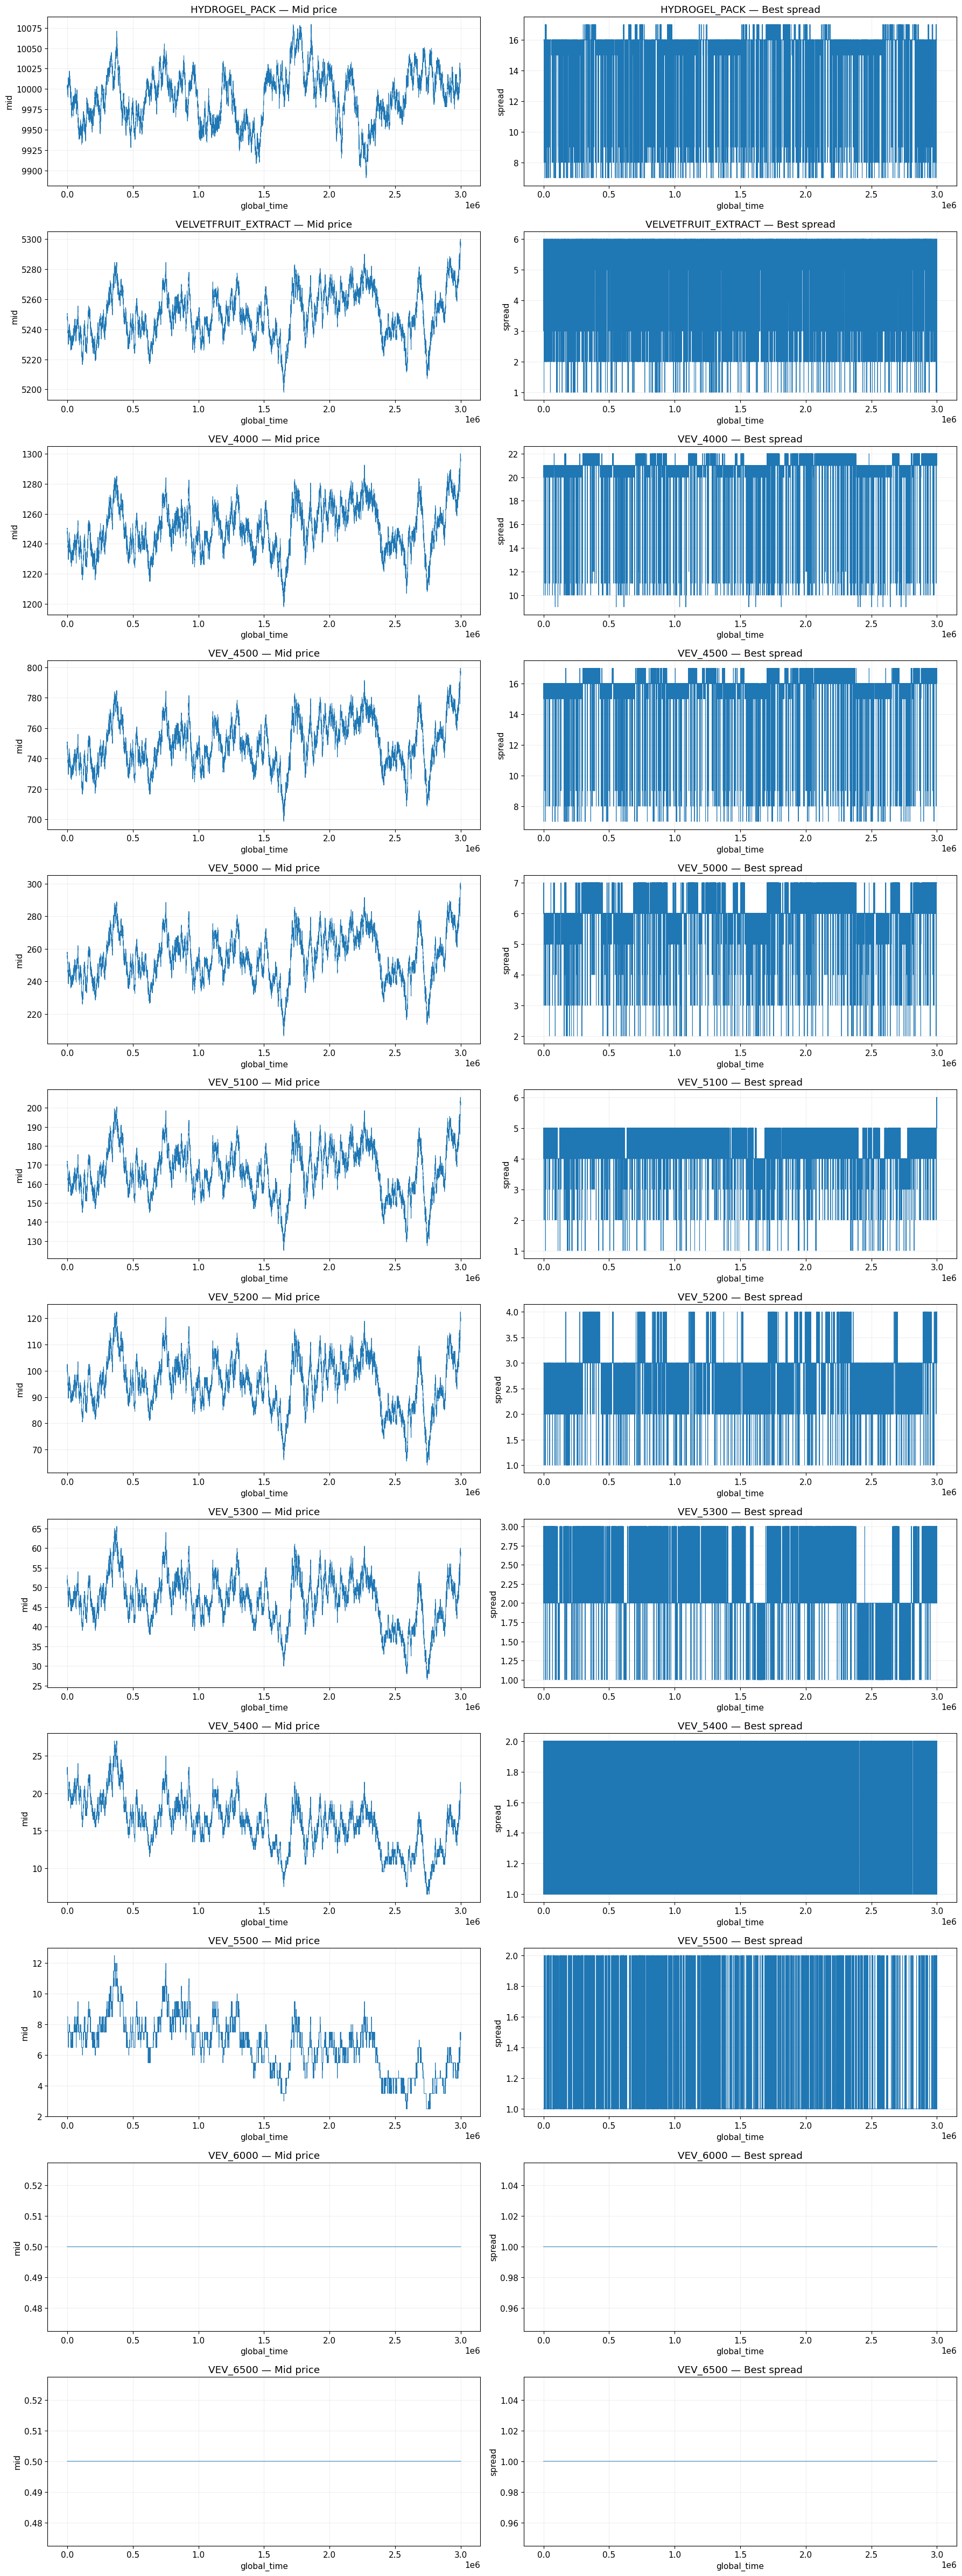

In [4]:
fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(18, 4 * len(PRODUCTS)), sharex=False)
for i, p in enumerate(PRODUCTS):
    x = prices[prices["product"] == p].sort_values("global_time")
    axes[i, 0].plot(x["global_time"], x["mid_price"], lw=0.7)
    axes[i, 0].set_title(f"{p} — Mid price")
    axes[i, 0].set_xlabel("global_time")
    axes[i, 0].set_ylabel("mid")

    axes[i, 1].plot(x["global_time"], x["spread"], lw=0.7)
    axes[i, 1].set_title(f"{p} — Best spread")
    axes[i, 1].set_xlabel("global_time")
    axes[i, 1].set_ylabel("spread")
plt.tight_layout()
plt.show()


## 4. Returns, volatility, and mean reversion / momentum diagnostics

Good trading decisions depend on whether the product is:
- stationary around a fair value,
- trending,
- or mean-reverting with a short half-life.

For each product, inspect:
- lag-1 autocorrelation of returns,
- return volatility,
- Hurst-style trend/mean-reversion behavior,
- rolling volatility changes.


HYDROGEL_PACK        lag1 ACF=-0.1292 | Hurst= 0.474 | half-life= 300.9
VELVETFRUIT_EXTRACT  lag1 ACF=-0.1588 | Hurst= 0.480 | half-life= 279.6
VEV_4000             lag1 ACF=-0.2844 | Hurst= 0.459 | half-life= 174.9
VEV_4500             lag1 ACF=-0.2251 | Hurst= 0.472 | half-life= 226.2
VEV_5000             lag1 ACF=-0.0996 | Hurst= 0.486 | half-life= 316.5
VEV_5100             lag1 ACF=-0.0980 | Hurst= 0.488 | half-life= 326.7
VEV_5200             lag1 ACF=-0.1349 | Hurst= 0.481 | half-life= 283.3
VEV_5300             lag1 ACF=-0.2198 | Hurst= 0.467 | half-life= 221.0
VEV_5400             lag1 ACF=-0.2500 | Hurst= 0.447 | half-life= 220.4
VEV_5500             lag1 ACF=-0.2412 | Hurst= 0.349 | half-life= 131.5
VEV_6000             lag1 ACF= nan | Hurst= nan | half-life= nan
VEV_6500             lag1 ACF= nan | Hurst= nan | half-life= nan


c:\Users\amans\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\amans\AppData\Local\Temp\ipykernel_29104\247720475.py:22: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(lag.values, ret.values, 1)[0]
c:\Users\amans\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\amans\AppData\Local\Temp\ipykernel_29104\247720475.py:22: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(lag.values, ret.values, 1)[0]


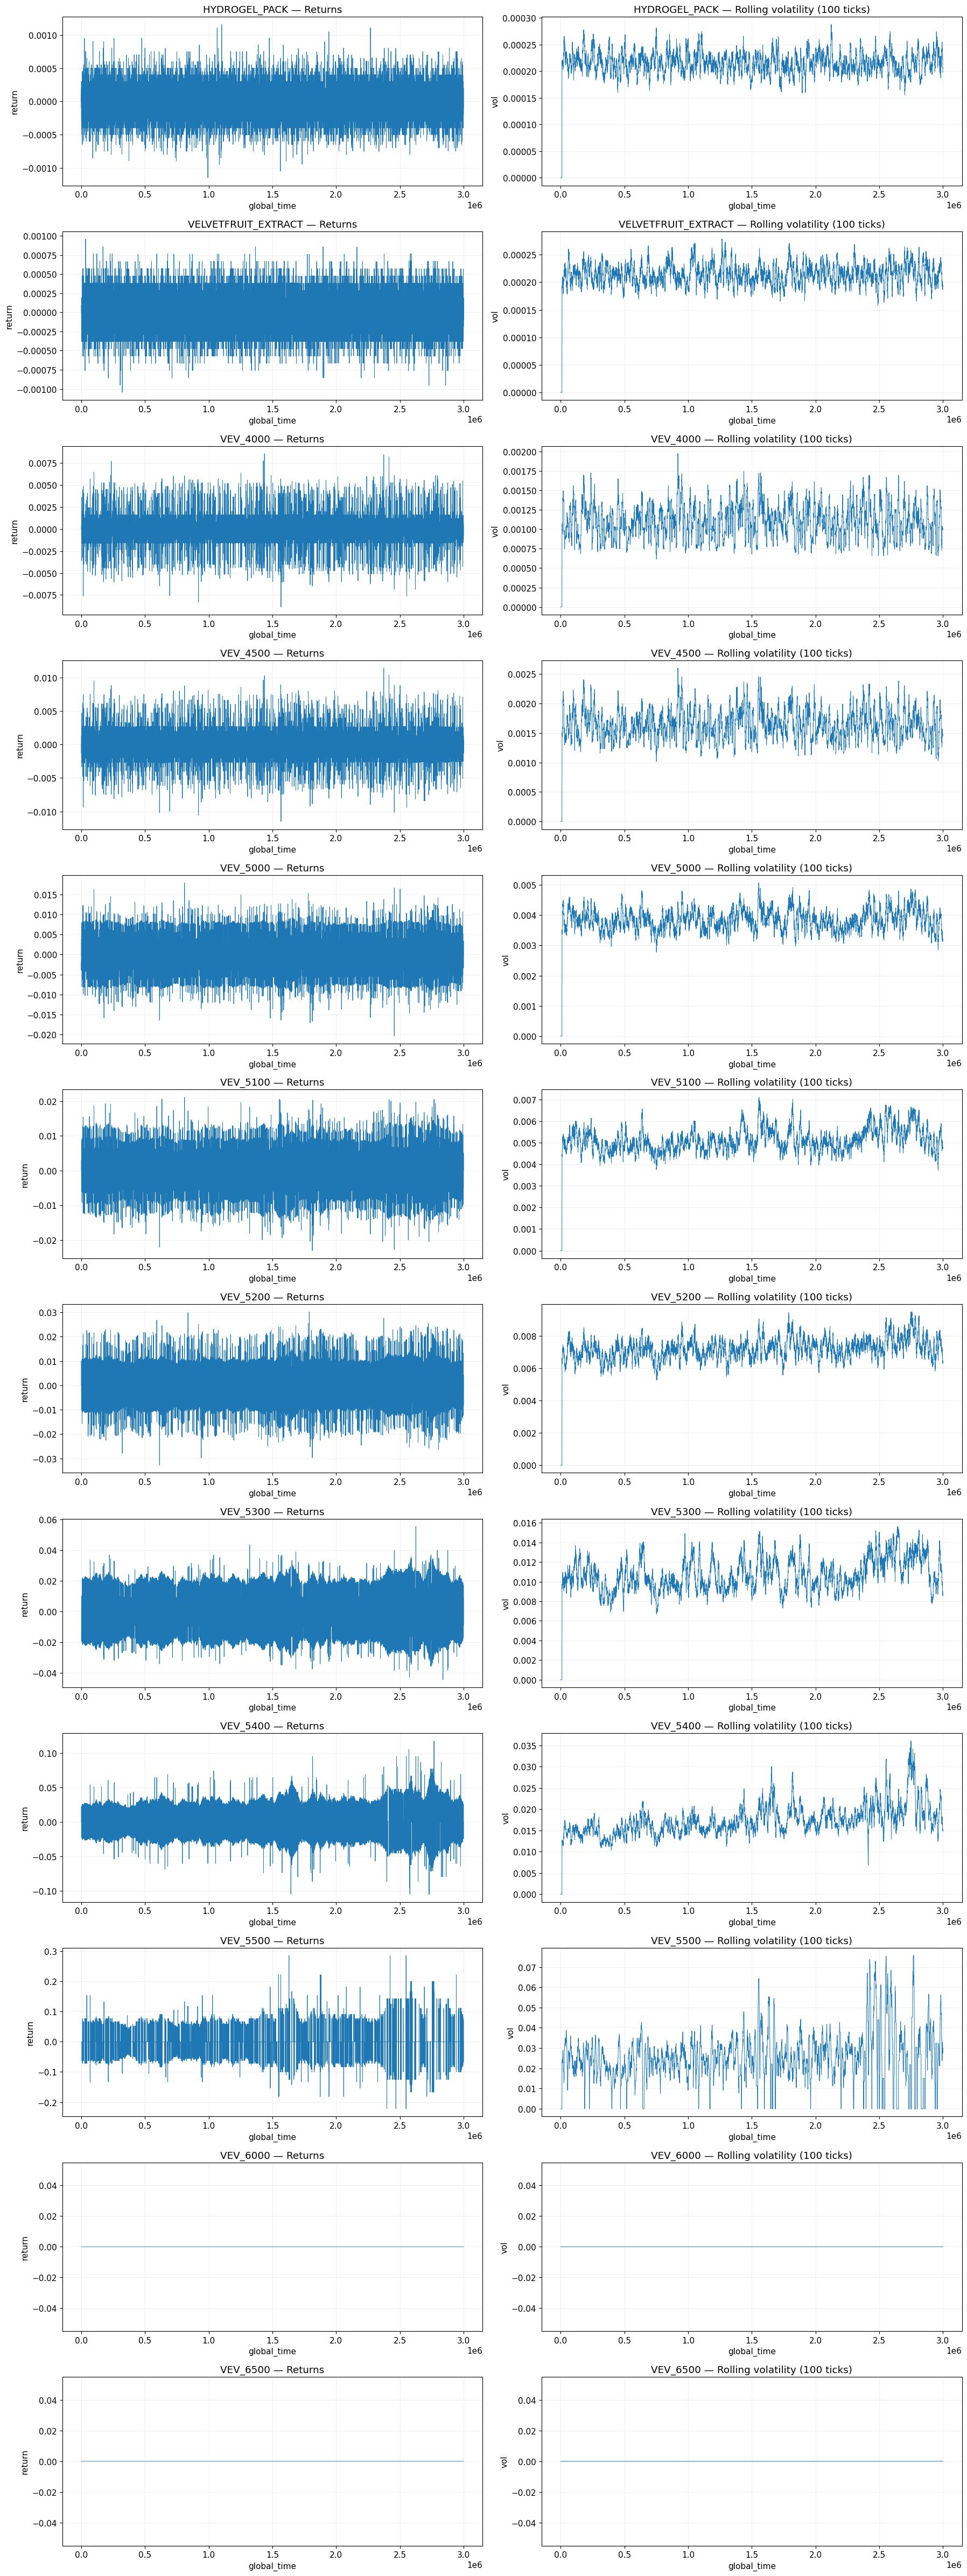

In [5]:
def hurst_exponent(ts: np.ndarray, max_lag: int = 100) -> float:
    ts = np.asarray(ts, dtype=float)
    ts = ts[np.isfinite(ts)]
    if len(ts) < max_lag + 5:
        return np.nan
    lags = range(2, max_lag)
    tau = [np.std(ts[lag:] - ts[:-lag]) for lag in lags]
    tau = np.array(tau)
    good = np.isfinite(tau) & (tau > 0)
    if good.sum() < 2:
        return np.nan
    slope, _ = np.polyfit(np.log(np.array(list(lags))[good]), np.log(tau[good]), 1)
    return float(slope)

def mean_reversion_halflife(series: pd.Series) -> float:
    x = series.dropna().astype(float)
    if len(x) < 30:
        return np.nan
    lag = x.shift(1).dropna()
    ret = x.diff().dropna()
    lag = lag.loc[ret.index]
    beta = np.polyfit(lag.values, ret.values, 1)[0]
    if beta >= 0:
        return np.nan
    return float(-np.log(2) / beta)

fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(18, 4 * len(PRODUCTS)))
for i, p in enumerate(PRODUCTS):
    x = prices[prices["product"] == p].sort_values("global_time")
    mid = x["mid_price"].astype(float)
    ret = mid.pct_change().dropna()

    axes[i, 0].plot(x["global_time"], ret.reindex(x.index).fillna(0), lw=0.6)
    axes[i, 0].set_title(f"{p} — Returns")
    axes[i, 0].set_xlabel("global_time")
    axes[i, 0].set_ylabel("return")

    roll_vol = ret.rolling(100).std()
    axes[i, 1].plot(x["global_time"], roll_vol.reindex(x.index).fillna(0), lw=0.7)
    axes[i, 1].set_title(f"{p} — Rolling volatility (100 ticks)")
    axes[i, 1].set_xlabel("global_time")
    axes[i, 1].set_ylabel("vol")

    if len(ret) > 10:
        print(
            f"{p:20s} lag1 ACF={ret.autocorr(1): .4f} | "
            f"Hurst={hurst_exponent(mid.values): .3f} | "
            f"half-life={mean_reversion_halflife(mid): .1f}"
        )
plt.tight_layout()
plt.show()


## 5. Intraday pattern analysis

For some products the real edge is not in one global fair value, but in a structured intraday curve.

This section shows:
- average demeaned price by timestamp within a day,
- how much the curve differs across days,
- the peak and trough times of day.

That is especially useful if a product has a repeatable day shape and you want to build a time-of-day strategy.


HYDROGEL_PACK        peak=725800 trough=91200 range=108.00
VELVETFRUIT_EXTRACT  peak=928300 trough=649100 range=56.17
VEV_4000             peak=927600 trough=649300 range=56.83
VEV_4500             peak=927600 trough=649300 range=56.33
VEV_5000             peak=928300 trough=649300 range=52.33
VEV_5100             peak=928300 trough=649300 range=45.67
VEV_5200             peak=928300 trough=649300 range=33.50
VEV_5300             peak=928300 trough=649200 range=20.67
VEV_5400             peak=299300 trough=649300 range=9.17
VEV_5500             peak=249800 trough=616600 range=4.17
VEV_6000             peak=0 trough=0 range=0.00
VEV_6500             peak=0 trough=0 range=0.00


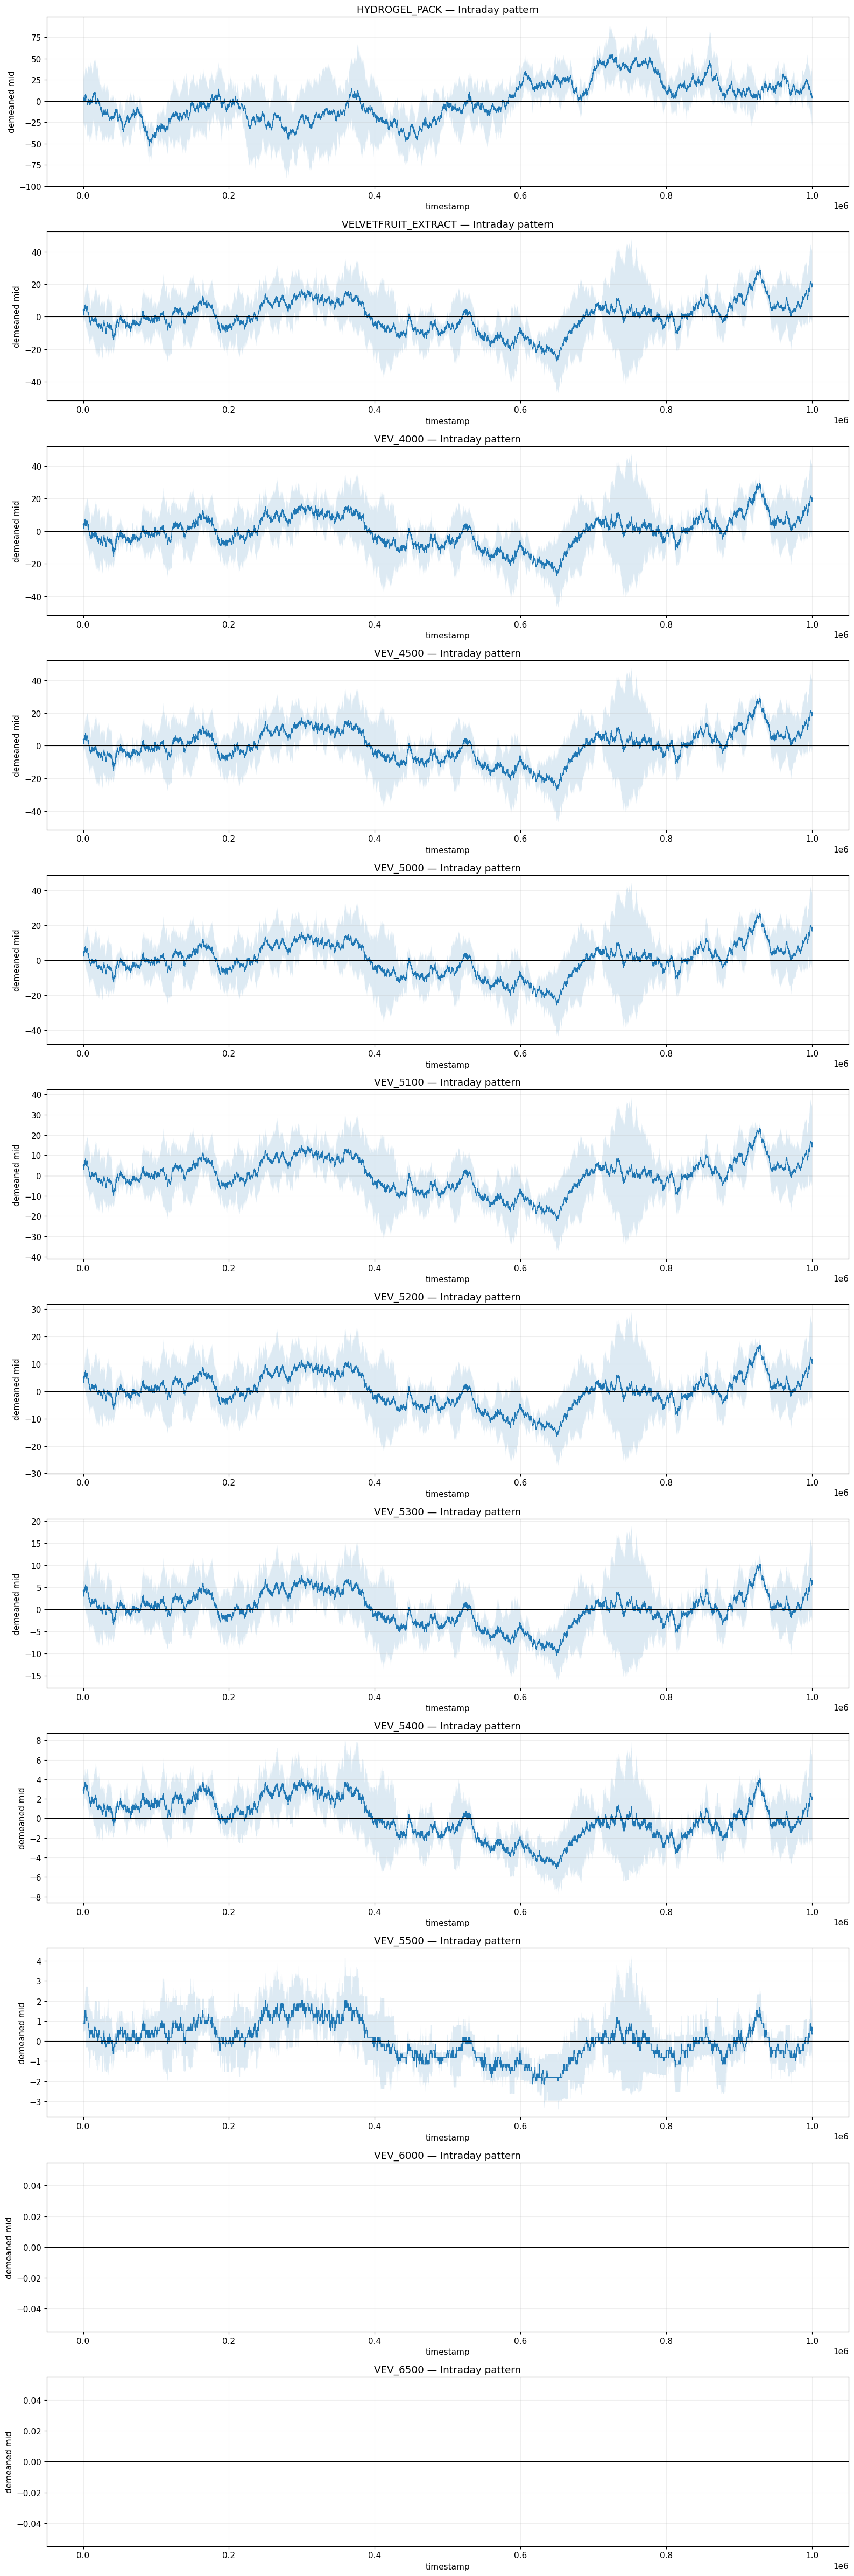

In [6]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4 * len(PRODUCTS)))
for i, p in enumerate(PRODUCTS):
    x = prices[prices["product"] == p].copy()
    x["demeaned"] = x.groupby("day")["mid_price"].transform(lambda s: s - s.mean())
    avg = x.groupby("timestamp")["demeaned"].mean()
    std = x.groupby("timestamp")["demeaned"].std()

    axes[i].plot(avg.index, avg.values, lw=1.0, label="avg demeaned price")
    axes[i].fill_between(avg.index, (avg - std).values, (avg + std).values, alpha=0.15)
    axes[i].axhline(0, color="black", lw=0.8)
    axes[i].set_title(f"{p} — Intraday pattern")
    axes[i].set_xlabel("timestamp")
    axes[i].set_ylabel("demeaned mid")
    peak_ts = avg.idxmax()
    trough_ts = avg.idxmin()
    print(f"{p:20s} peak={peak_ts} trough={trough_ts} range={avg.max()-avg.min():.2f}")
plt.tight_layout()
plt.show()


## 6. Trade-flow analysis

The trade file tells you where the market actually transacted.

Useful questions:
- Which products trade the most?
- Are some prices repeatedly printed?
- Are trades clustered around one side of the book?
- Does the trade flow confirm or reject your fair-value estimate?
- Is there visible adverse selection after the trade?

Look at:
- trade counts,
- volume by price,
- scatter of trade price vs time,
- buy/sell direction if trader IDs are available.


Trade counts by symbol:
                     count   sum  mean
symbol                                
VELVETFRUIT_EXTRACT   1372  8269  6.03
HYDROGEL_PACK         1010  4078  4.04
VEV_4000               464   940  2.03
VEV_6000               284  1002  3.53
VEV_6500               284  1002  3.53
VEV_5500               267   937  3.51
VEV_5400               225   787  3.50
VEV_5300               121   420  3.47
VEV_5200                18    63  3.50
VEV_4500                 1     1  1.00
VEV_5000                 1     1  1.00
VEV_5100                 1     1  1.00


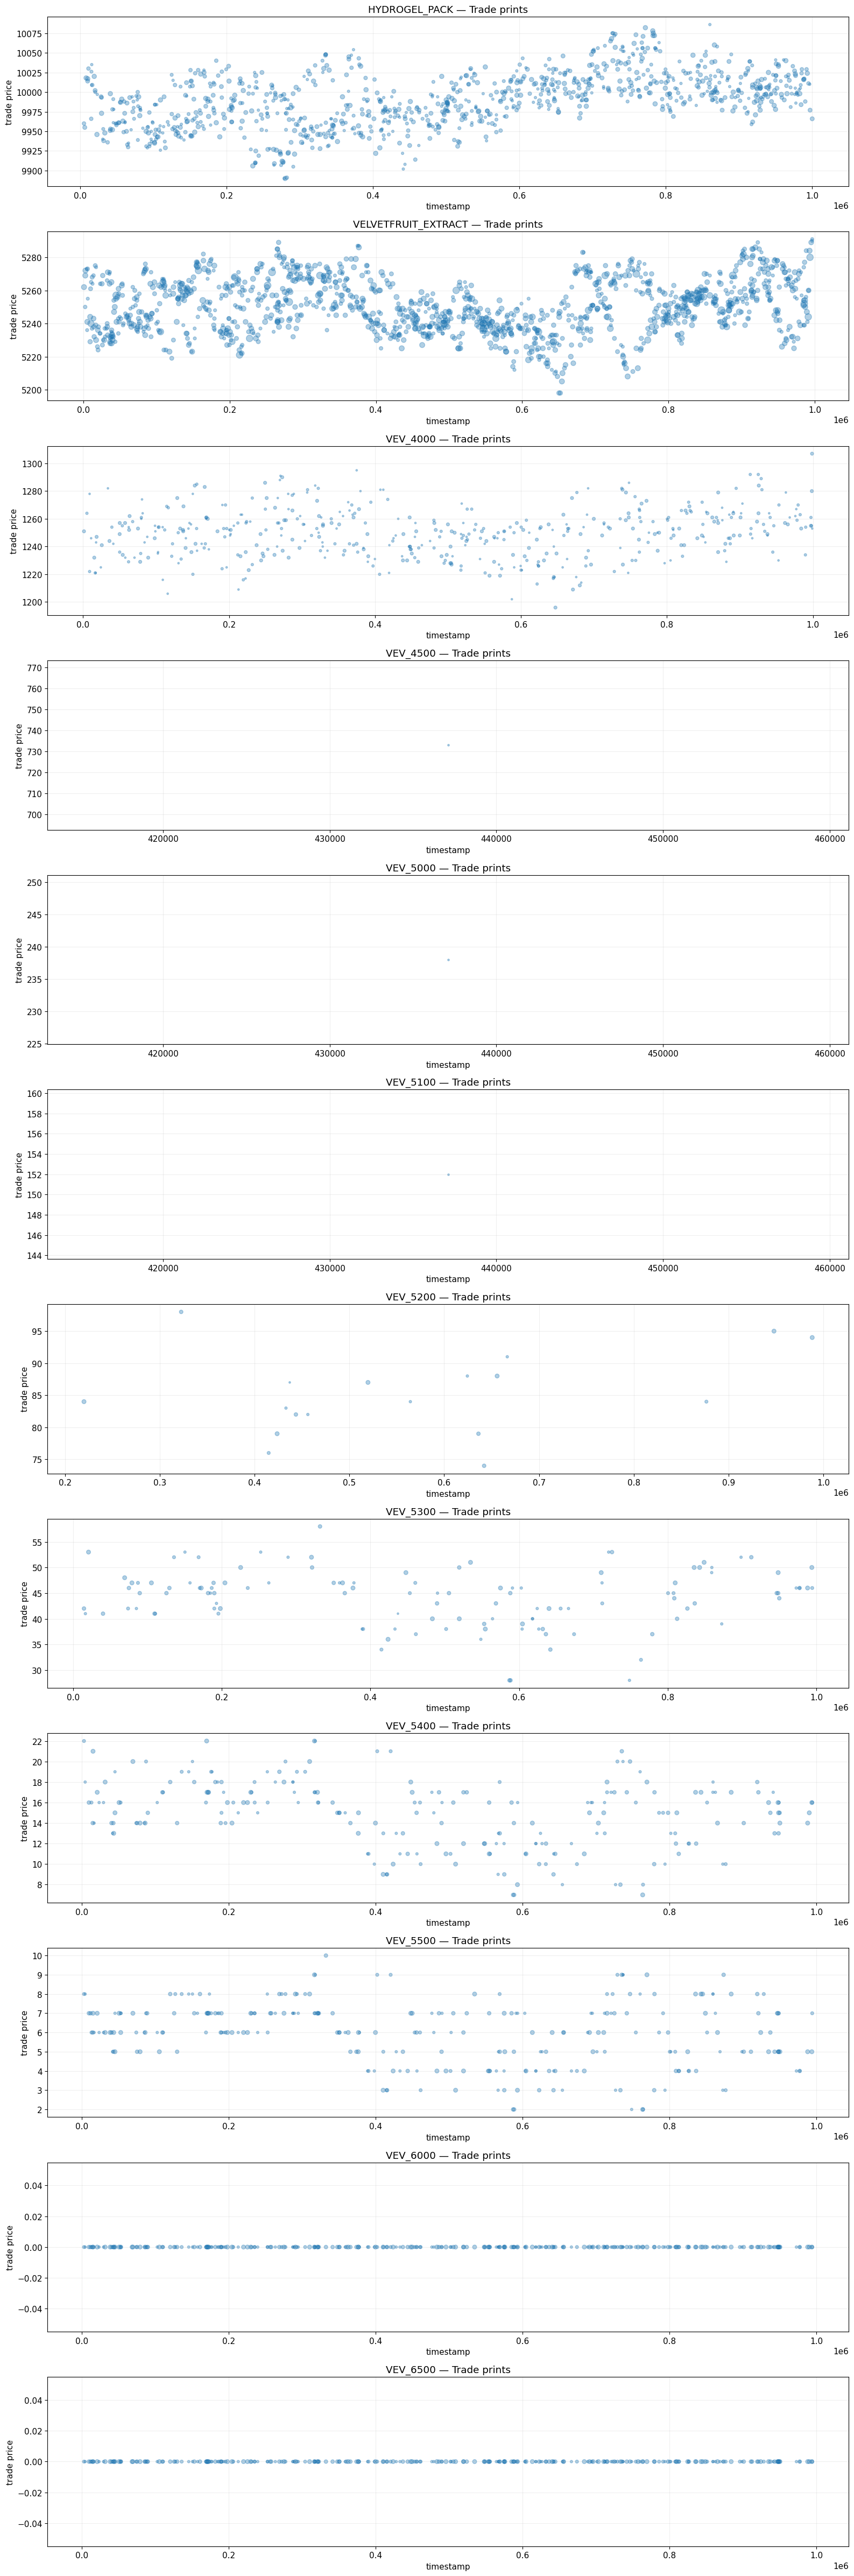

In [7]:
print("Trade counts by symbol:")
print(trades.groupby("symbol")["quantity"].agg(["count", "sum", "mean"]).sort_values("count", ascending=False).round(2))

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(16, 4 * len(PRODUCTS)))
for i, p in enumerate(PRODUCTS):
    td = trades[trades["symbol"] == p].copy()
    axes[i].set_title(f"{p} — Trade prints")
    if td.empty:
        axes[i].text(0.5, 0.5, "No trades", ha="center", va="center")
        continue
    axes[i].scatter(td["timestamp"], td["price"], s=np.clip(td["quantity"].abs(), 1, 30) * 6, alpha=0.35)
    axes[i].set_xlabel("timestamp")
    axes[i].set_ylabel("trade price")
plt.tight_layout()
plt.show()


## 7. Spot-product microstructure analysis

For `HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT`, you usually want to understand:
- the fair value level,
- whether a simple EMA is better than a hardcoded price,
- whether order book imbalance predicts next returns,
- whether the product trends enough to make symmetric market making dangerous.

These are the core spot products in this round and often the source of most PnL and most drawdown.


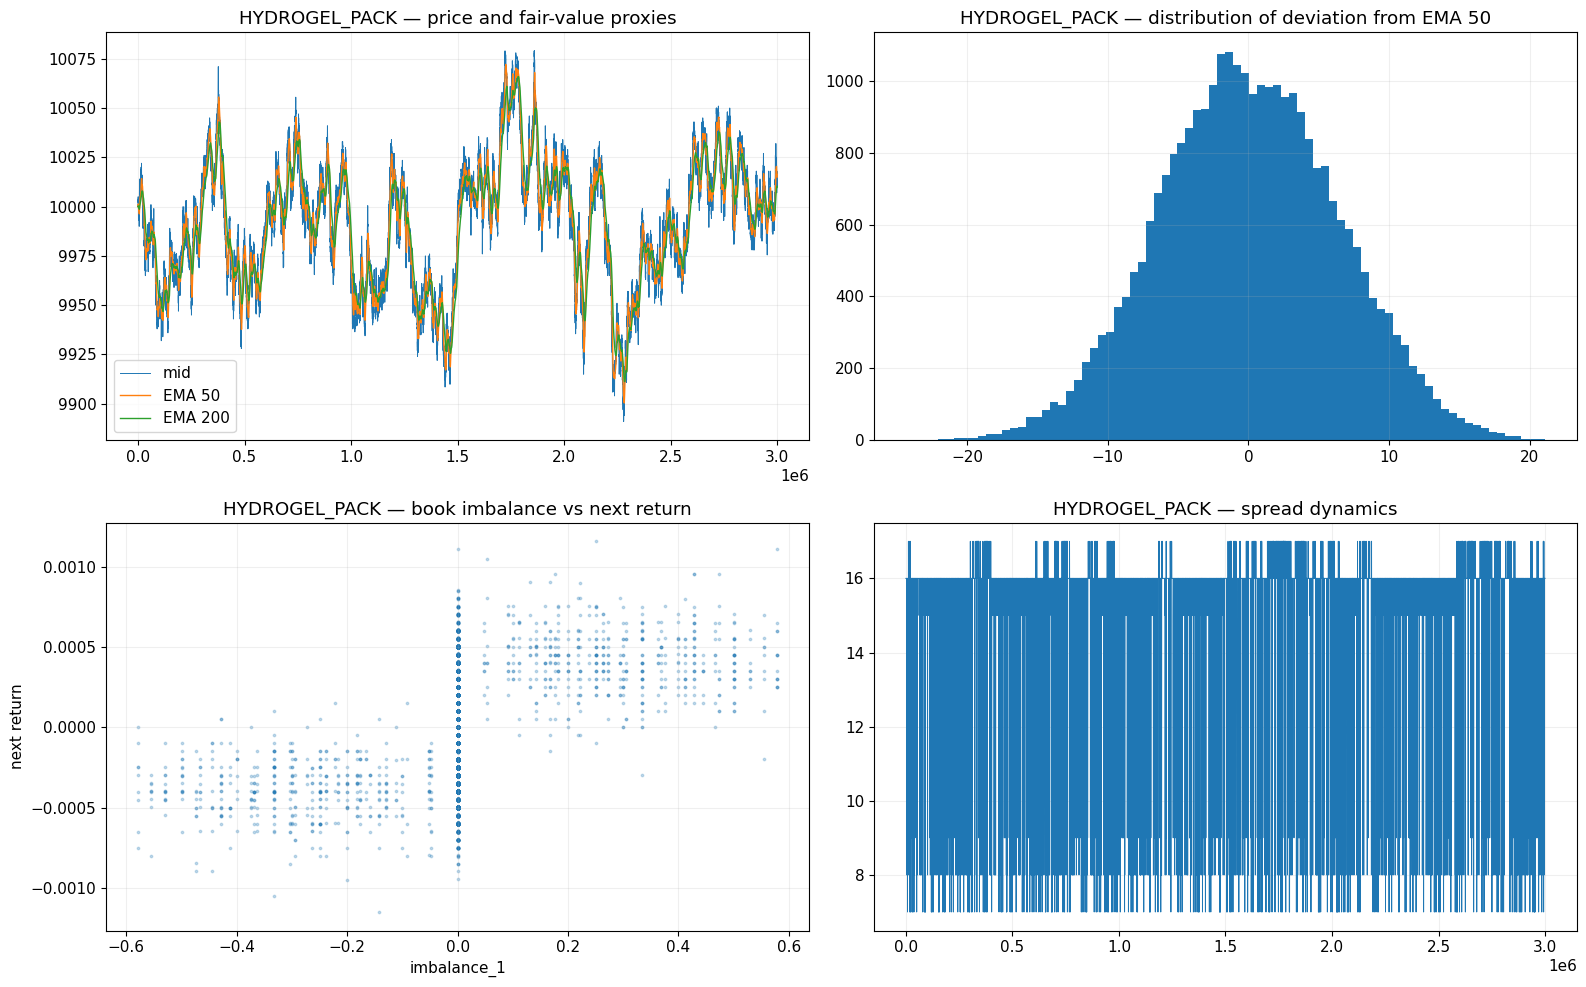

HYDROGEL_PACK: corr(imbalance_1, next_ret) = 0.2989
HYDROGEL_PACK: corr(dev_ema, next_ret)      = -0.0485



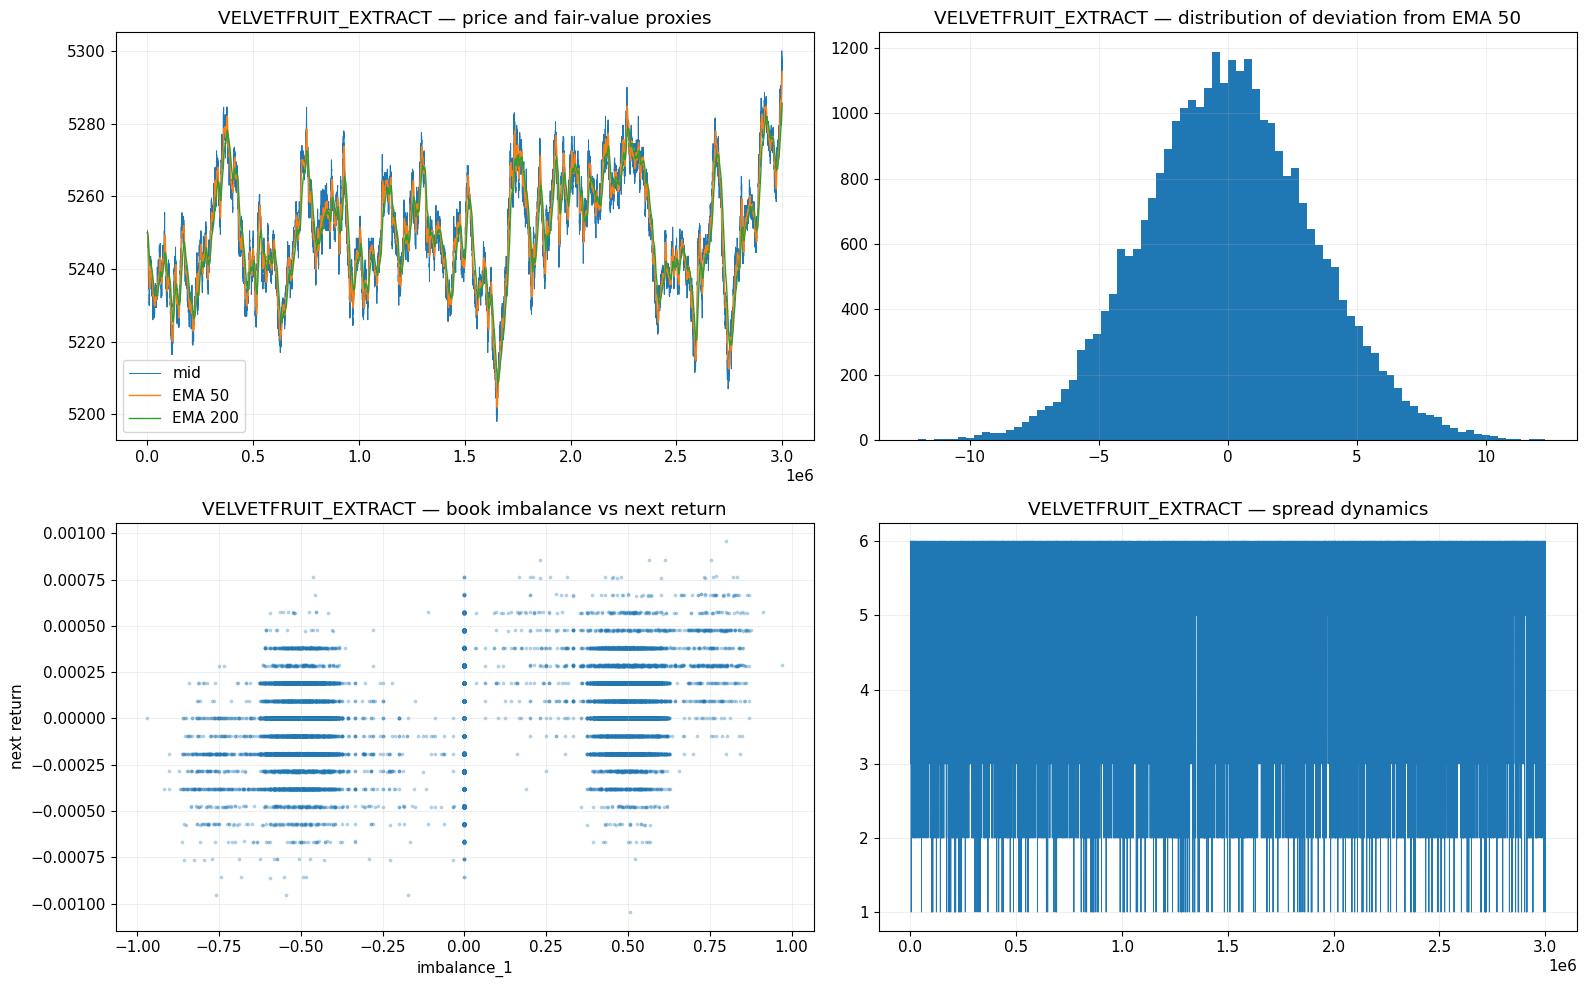

VELVETFRUIT_EXTRACT: corr(imbalance_1, next_ret) = 0.2807
VELVETFRUIT_EXTRACT: corr(dev_ema, next_ret)      = -0.0524



In [8]:
def next_return_signal(df: pd.DataFrame, horizon: int = 1) -> pd.Series:
    return df["mid_price"].shift(-horizon) / df["mid_price"] - 1.0

for p in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    x = prices[prices["product"] == p].sort_values("global_time").copy()
    x["ema_50"] = x["mid_price"].ewm(span=50, adjust=False).mean()
    x["ema_200"] = x["mid_price"].ewm(span=200, adjust=False).mean()
    x["dev_ema"] = x["mid_price"] - x["ema_50"]
    x["next_ret"] = next_return_signal(x, 1)

    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    ax[0,0].plot(x["global_time"], x["mid_price"], lw=0.7, label="mid")
    ax[0,0].plot(x["global_time"], x["ema_50"], lw=1.0, label="EMA 50")
    ax[0,0].plot(x["global_time"], x["ema_200"], lw=1.0, label="EMA 200")
    ax[0,0].set_title(f"{p} — price and fair-value proxies")
    ax[0,0].legend()

    ax[0,1].hist(x["dev_ema"].dropna(), bins=80)
    ax[0,1].set_title(f"{p} — distribution of deviation from EMA 50")

    ax[1,0].scatter(x["imbalance_1"], x["next_ret"], s=3, alpha=0.25)
    ax[1,0].set_title(f"{p} — book imbalance vs next return")
    ax[1,0].set_xlabel("imbalance_1")
    ax[1,0].set_ylabel("next return")

    ax[1,1].plot(x["global_time"], x["spread"], lw=0.7)
    ax[1,1].set_title(f"{p} — spread dynamics")
    plt.tight_layout()
    plt.show()

    print(f"{p}: corr(imbalance_1, next_ret) = {x['imbalance_1'].corr(x['next_ret']):.4f}")
    print(f"{p}: corr(dev_ema, next_ret)      = {x['dev_ema'].corr(x['next_ret']):.4f}")
    print()


## 7.5 Order Book Imbalance (OBI) & Micro-Price Formulation

The standard mid-price is a naive estimator of fair value. A rigorous market maker requires the **Micro-Price** ($P_{micro}$), which weights the spread by the **Order Book Imbalance** ($I$).

Let $Q_b$ and $Q_a$ be the volume at the best bid and ask. The Imbalance is:

$$I = \frac{Q_b - Q_a}{Q_b + Q_a} \in [-1, 1]$$

$$P_{micro} = P_{mid} + I \cdot \left(\frac{P_{ask} - P_{bid}}{2}\right)$$

When $I > 0$, there is more demand at the bid (bullish signal). When $I < 0$, there is more supply at the ask (bearish signal).

This section formally computes the OBI and validates its predictive power for short-term returns.


HYDROGEL_PACK — OBI Predictive Power:
  Slope: 10.194141 | R²: 0.0097 | p-value: 2.5336e-65
  Interpretation: 1 unit ↑ in OBI → 10.194 tick return in next 10 ticks

VELVETFRUIT_EXTRACT — OBI Predictive Power:
  Slope: 0.806124 | R²: 0.0111 | p-value: 1.3864e-74
  Interpretation: 1 unit ↑ in OBI → 0.806 tick return in next 10 ticks


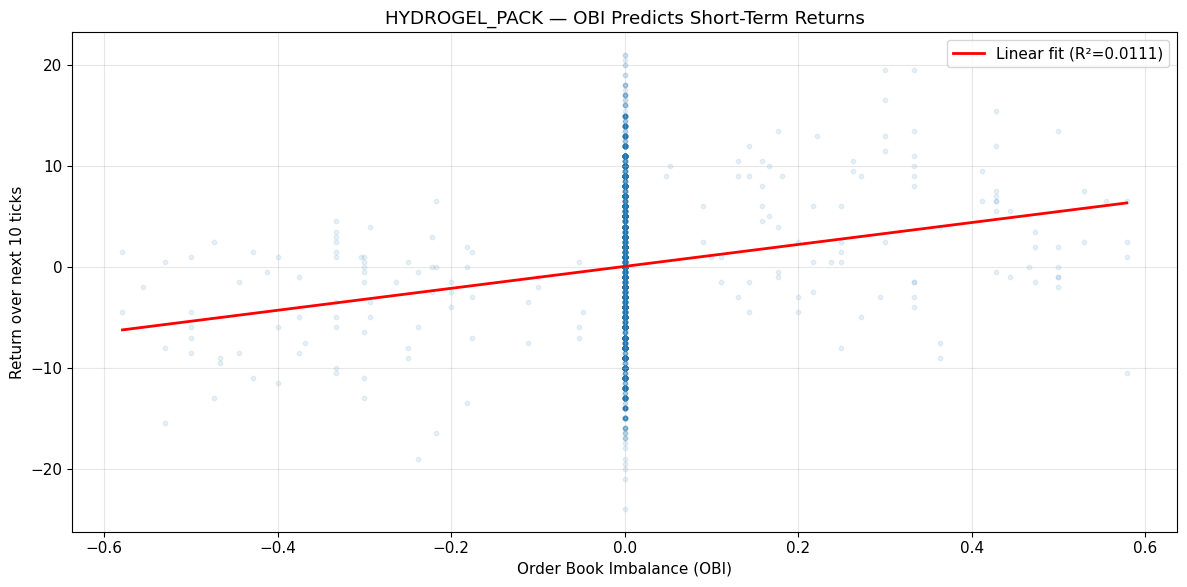

In [9]:
def compute_microstructure(df: pd.DataFrame) -> pd.DataFrame:
    """Compute OBI and micro-price for all products."""
    df = df.copy()
    df['OBI'] = (df['bid_volume_1'] - df['ask_volume_1']) / (df['bid_volume_1'] + df['ask_volume_1'] + 1e-9)
    df['micro_price'] = df['mid_price'] + df['OBI'] * (df['spread'] / 2.0)
    
    # Calculate short-term future returns (10 ticks ahead)
    df['future_mid_10'] = df.groupby('product')['mid_price'].shift(-10)
    df['return_10t'] = df['future_mid_10'] - df['mid_price']
    return df

prices = compute_microstructure(prices)

# Formal test of OBI predictive power for key products
for target_asset in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    asset_df = prices[prices['product'] == target_asset].dropna(subset=['OBI', 'return_10t'])
    if len(asset_df) < 10:
        print(f"{target_asset}: insufficient data")
        continue
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(asset_df['OBI'], asset_df['return_10t'])
    print(f"\n{target_asset} — OBI Predictive Power:")
    print(f"  Slope: {slope:.6f} | R²: {r_value**2:.4f} | p-value: {p_value:.4e}")
    print(f"  Interpretation: 1 unit ↑ in OBI → {slope:.3f} tick return in next 10 ticks")

# Visualize OBI predictive power for HYDROGEL_PACK
target = "HYDROGEL_PACK"
asset_df = prices[prices['product'] == target].dropna(subset=['OBI', 'return_10t'])
if len(asset_df) > 100:
    sample_idx = np.random.choice(len(asset_df), min(5000, len(asset_df)), replace=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.scatter(asset_df['OBI'].iloc[sample_idx], asset_df['return_10t'].iloc[sample_idx], alpha=0.1, s=10)
    
    # Add regression line
    z = np.polyfit(asset_df['OBI'].iloc[sample_idx], asset_df['return_10t'].iloc[sample_idx], 1)
    p = np.poly1d(z)
    x_line = np.linspace(asset_df['OBI'].min(), asset_df['OBI'].max(), 100)
    ax.plot(x_line, p(x_line), "r-", lw=2, label=f'Linear fit (R²={r_value**2:.4f})')
    
    ax.set_xlabel('Order Book Imbalance (OBI)')
    ax.set_ylabel('Return over next 10 ticks')
    ax.set_title(f'{target} — OBI Predicts Short-Term Returns')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 8. A cleaner fair-value framework for spots

A practical live-trading rule set usually needs:
- a slow fair value,
- a faster fair value,
- and an inventory-aware quote skew.

The purpose is not to predict the exact next tick.
The purpose is to avoid getting filled when the market has a better informed view than you.


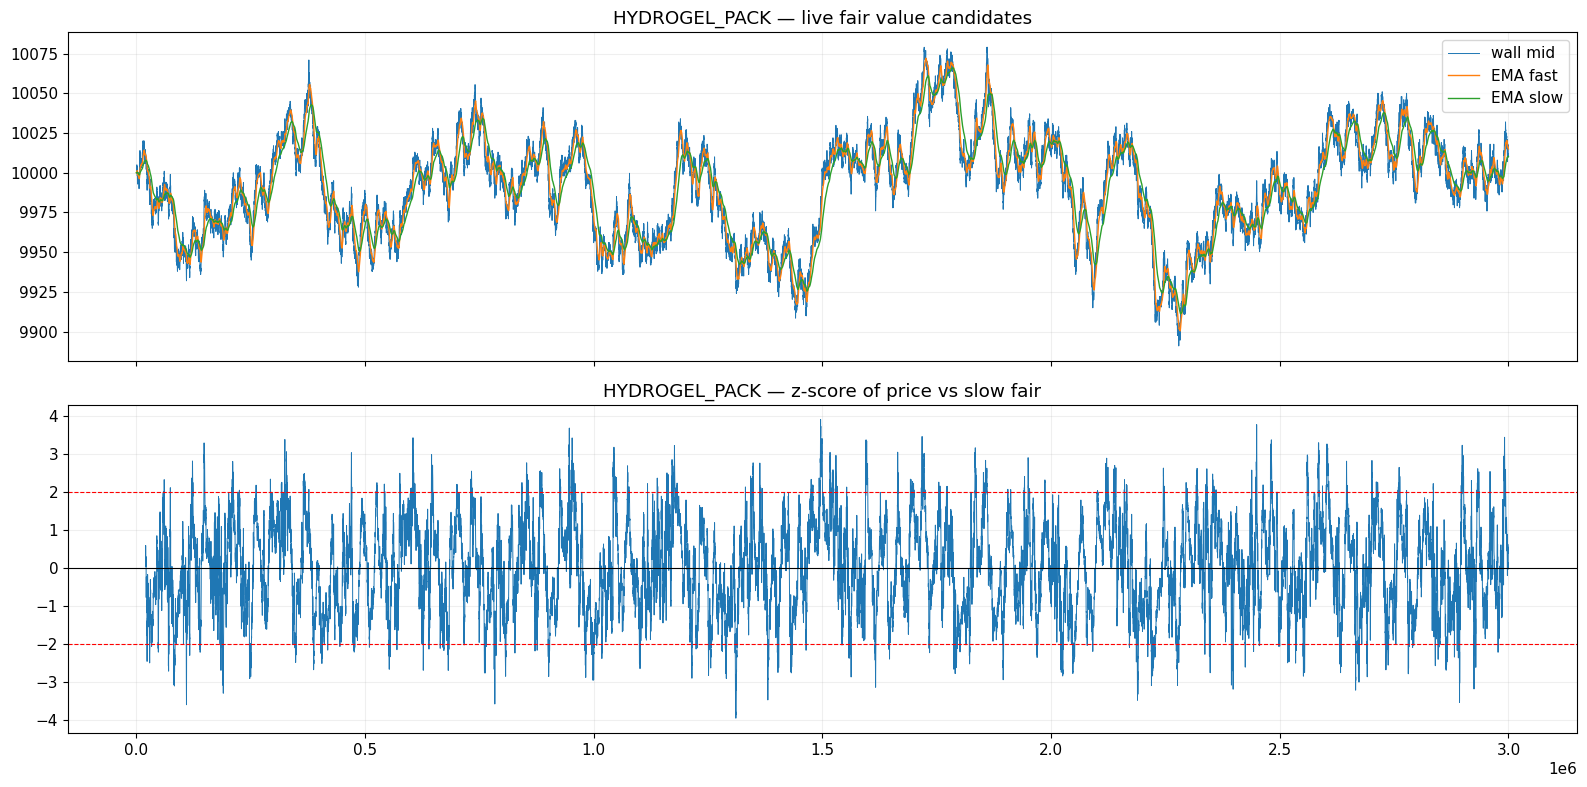

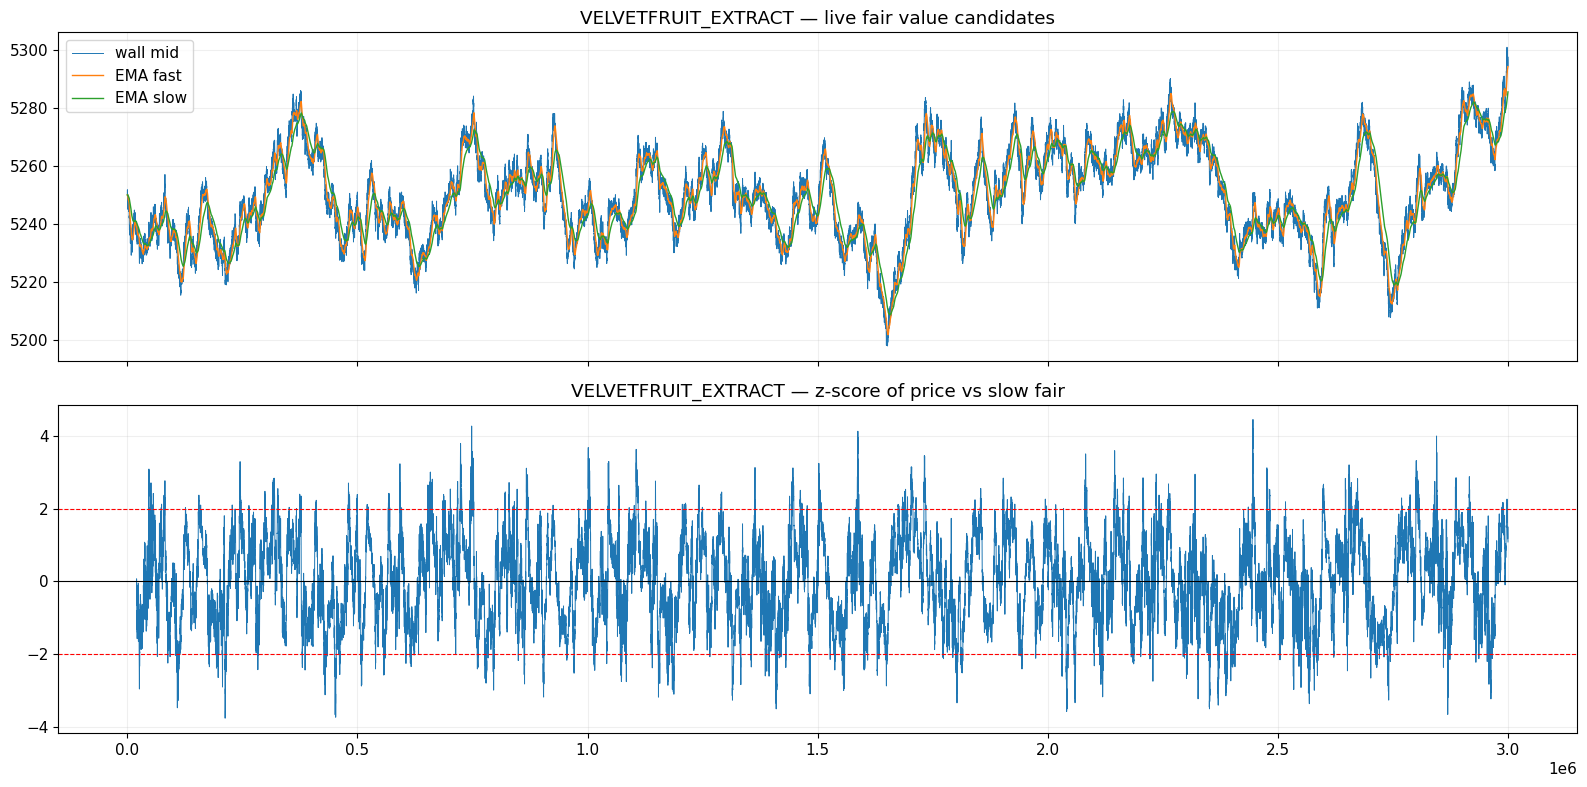

In [10]:
def wall_mid(row: pd.Series) -> float:
    bid_px = row["bid_price_1"]
    ask_px = row["ask_price_1"]
    bid_v = max(1, row["bid_volume_1"])
    ask_v = max(1, row["ask_volume_1"])
    return (bid_px * ask_v + ask_px * bid_v) / (bid_v + ask_v)

def make_spot_diagnostics(product: str, span_fast: int = 50, span_slow: int = 200):
    x = prices[prices["product"] == product].sort_values("global_time").copy()
    x["wall_mid"] = x.apply(wall_mid, axis=1)
    x["ema_fast"] = x["wall_mid"].ewm(span=span_fast, adjust=False).mean()
    x["ema_slow"] = x["wall_mid"].ewm(span=span_slow, adjust=False).mean()
    x["trend"] = x["ema_fast"] - x["ema_slow"]
    x["z"] = (x["wall_mid"] - x["ema_slow"]) / (x["wall_mid"].rolling(200).std() + 1e-9)
    return x

for p in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    x = make_spot_diagnostics(p)
    fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    ax[0].plot(x["global_time"], x["wall_mid"], lw=0.7, label="wall mid")
    ax[0].plot(x["global_time"], x["ema_fast"], lw=1.0, label="EMA fast")
    ax[0].plot(x["global_time"], x["ema_slow"], lw=1.0, label="EMA slow")
    ax[0].legend()
    ax[0].set_title(f"{p} — live fair value candidates")

    ax[1].plot(x["global_time"], x["z"], lw=0.7)
    ax[1].axhline(0, color="black", lw=0.8)
    ax[1].axhline(2, color="red", ls="--", lw=0.8)
    ax[1].axhline(-2, color="red", ls="--", lw=0.8)
    ax[1].set_title(f"{p} — z-score of price vs slow fair")
    plt.tight_layout()
    plt.show()


## 9. Black-Scholes helpers for vouchers

The voucher family is the most important part of the round.

The main objects to compute are:
- theoretical price,
- delta,
- implied volatility,
- strike-by-strike smile,
- mispricing residuals.

Use the underlying `VELVETFRUIT_EXTRACT` fair value as `S`, the strike from the voucher name as `K`, and the remaining time to expiry as `T`.


In [11]:
def ncdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_call(S: float, K: float, T: float, sigma: float) -> float:
    if S <= 0:
        return 0.0
    if T <= 1e-12:
        return max(S - K, 0.0)
    sigma = max(1e-8, sigma)
    vol = sigma * math.sqrt(T)
    if vol <= 1e-12:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / vol
    d2 = d1 - vol
    return S * ncdf(d1) - K * ncdf(d2)

def bs_delta(S: float, K: float, T: float, sigma: float) -> float:
    if S <= 0:
        return 0.0
    if T <= 1e-12:
        return 1.0 if S > K else 0.0
    sigma = max(1e-8, sigma)
    vol = sigma * math.sqrt(T)
    if vol <= 1e-12:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + 0.5 * sigma * sigma * T) / vol
    return ncdf(d1)

def implied_vol_from_price(price: float, S: float, K: float, T: float) -> Optional[float]:
    intrinsic = max(S - K, 0.0)
    if price <= intrinsic + 1e-9 or T <= 1e-12 or S <= 0:
        return None
    lo, hi = 0.01, 1.5
    try:
        if bs_call(S, K, T, hi) < price:
            return None
    except Exception:
        return None
    for _ in range(60):
        mid = (lo + hi) / 2.0
        val = bs_call(S, K, T, mid)
        if abs(val - price) < 1e-6:
            return mid
        if val < price:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0

def tte_years(timestamp: int, start_days: float = TTE_START_DAYS) -> float:
    days_left = max(start_days - timestamp / TICKS_PER_DAY, 0.01)
    return days_left / TRADING_DAYS


## 10. Voucher smile analysis

This is where the round becomes an options problem instead of a plain spot problem.

For each timestamp:
1. estimate the underlying fair value `S`,
2. compute each voucher's theoretical price,
3. invert to implied volatility if needed,
4. compare the smile across strikes.

Questions to answer:
- which strike is systematically cheap?
- which strike is systematically rich?
- does the smile stay stable or move with time?
- are some strikes essentially pure premium?


In [12]:
def analyse_smile(day: int, sigma_guess: float = 0.215, fair_span: int = 100) -> pd.DataFrame:
    d = prices[prices["day"] == day].copy().sort_values(["timestamp", "product"])
    ve = d[d["product"] == "VELVETFRUIT_EXTRACT"].copy()
    ve["fair"] = ve["mid_price"].ewm(span=fair_span, adjust=False).mean()
    fair_by_time = ve.groupby("timestamp")["fair"].last()

    rows = []
    for sym, K in STRIKES.items():
        opt = d[d["product"] == sym].copy()
        if opt.empty:
            continue
        tmp = opt[["timestamp", "mid_price", "bid_price_1", "ask_price_1"]].copy()
        tmp["fair_S"] = tmp["timestamp"].map(fair_by_time)
        tmp["T"] = tmp["timestamp"].apply(lambda t: tte_years(t))
        tmp["theo"] = tmp.apply(lambda r: bs_call(r["fair_S"], K, r["T"], sigma_guess) if pd.notna(r["fair_S"]) else np.nan, axis=1)
        tmp["iv"] = tmp.apply(lambda r: implied_vol_from_price(r["mid_price"], r["fair_S"], K, r["T"]) if pd.notna(r["fair_S"]) else np.nan, axis=1)
        tmp["residual"] = tmp["mid_price"] - tmp["theo"]
        rows.append({
            "symbol": sym,
            "K": K,
            "mean_mid": tmp["mid_price"].mean(),
            "mean_theo": tmp["theo"].mean(),
            "mean_residual": tmp["residual"].mean(),
            "median_iv": tmp["iv"].median(),
            "iv_std": tmp["iv"].std(),
            "trade_count": int((trades["symbol"] == sym).sum()),
        })
    return pd.DataFrame(rows).sort_values("K")

smile_day0 = analyse_smile(0)
smile_day1 = analyse_smile(1)
smile_day2 = analyse_smile(2)

display(smile_day0.round(4))
display(smile_day1.round(4))
display(smile_day2.round(4))


,symbol,K,mean_mid,mean_theo,mean_residual,median_iv,iv_std,trade_count
0,VEV_4000,4000,1246.5241,1246.5411,-0.0170,0.9392,0.1249,464
1,VEV_4500,4500,746.5216,746.5411,-0.0195,0.5731,0.0836,1
2,VEV_5000,5000,253.2595,249.4835,3.7760,0.2618,0.0407,1
3,VEV_5100,5100,168.1077,159.4154,8.6923,0.2613,0.0197,1
4,VEV_5200,5200,97.4709,86.1867,11.2842,0.2569,0.0121,18
5,VEV_5300,5300,48.8925,37.5988,11.2937,0.2572,0.0083,121
6,VEV_5400,5400,18.4672,12.7624,5.7048,0.2458,0.0060,225
7,VEV_5500,5500,8.0590,3.2975,4.7615,0.2637,0.0081,267
8,VEV_6000,6000,0.5000,0.0001,0.4999,0.3935,0.0124,284
9,VEV_6500,6500,0.5000,0.0000,0.5000,0.5975,0.0184,284


,symbol,K,mean_mid,mean_theo,mean_residual,median_iv,iv_std,trade_count
0,VEV_4000,4000,1248.4080,1248.2925,0.1155,0.9458,0.1319,464
1,VEV_4500,4500,748.4052,748.2925,0.1128,0.5772,0.0885,1
2,VEV_5000,5000,253.2630,251.1543,2.1087,0.2503,0.0421,1
3,VEV_5100,5100,164.9832,160.9008,4.0824,0.2379,0.0229,1
4,VEV_5200,5200,95.1284,87.3176,7.8108,0.2441,0.0115,18
5,VEV_5300,5300,46.9092,38.2842,8.6250,0.2466,0.0090,121
6,VEV_5400,5400,15.6542,13.0770,2.5772,0.2291,0.0049,225
7,VEV_5500,5500,6.5708,3.4043,3.1665,0.2493,0.0048,267
8,VEV_6000,6000,0.5000,0.0001,0.4999,0.3927,0.0134,284
9,VEV_6500,6500,0.5000,0.0000,0.5000,0.5960,0.0192,284


,symbol,K,mean_mid,mean_theo,mean_residual,median_iv,iv_std,trade_count
0,VEV_4000,4000,1255.3974,1255.2770,0.1203,0.9322,0.1337,464
1,VEV_4500,4500,755.4018,755.2770,0.1248,0.5701,0.0900,1
2,VEV_5000,5000,258.5447,257.8378,0.7069,0.2383,0.0420,1
3,VEV_5100,5100,167.3254,166.8533,0.4721,0.2171,0.0243,1
4,VEV_5200,5200,94.0470,91.8621,2.1849,0.2231,0.0112,18
5,VEV_5300,5300,44.4781,41.0575,3.4206,0.2274,0.0068,121
6,VEV_5400,5400,13.7343,14.3674,-0.6331,0.2113,0.0053,225
7,VEV_5500,5500,5.2942,3.8516,1.4427,0.2313,0.0048,267
8,VEV_6000,6000,0.5000,0.0001,0.4999,0.3950,0.0157,284
9,VEV_6500,6500,0.5000,0.0000,0.5000,0.5970,0.0214,284


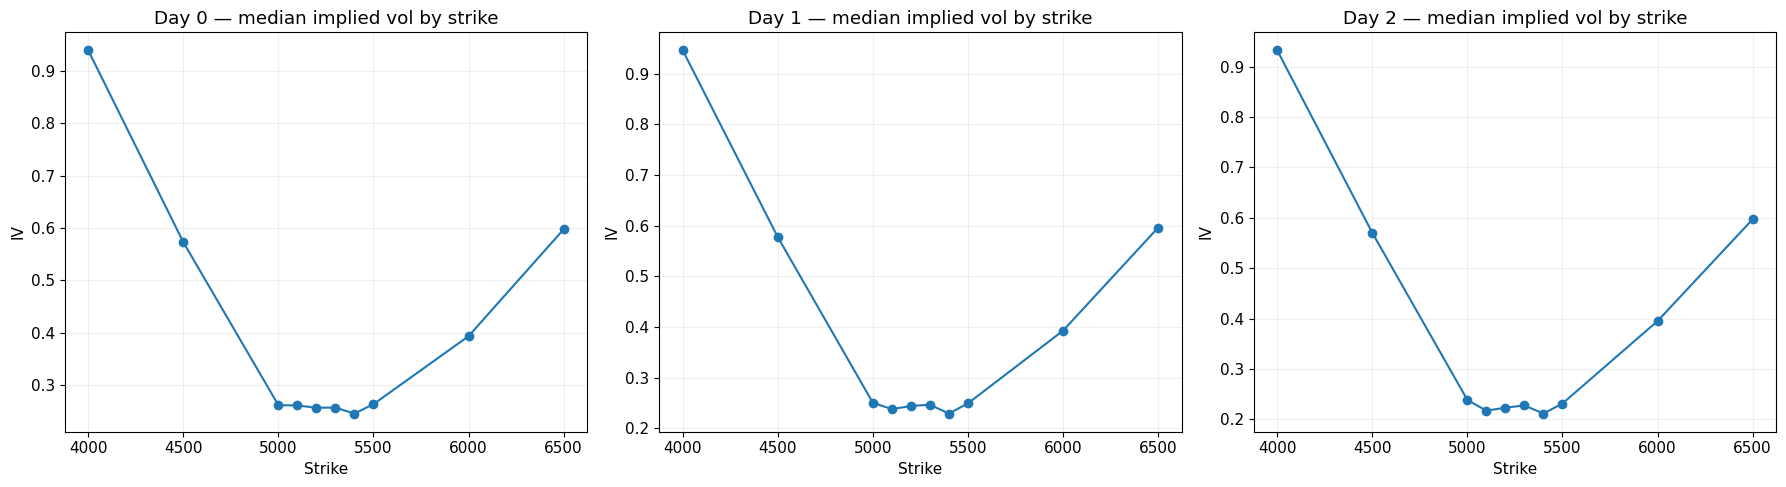

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, day in zip(axes, [0, 1, 2]):
    x = analyse_smile(day)
    ax.plot(x["K"], x["median_iv"], marker="o")
    ax.set_title(f"Day {day} — median implied vol by strike")
    ax.set_xlabel("Strike")
    ax.set_ylabel("IV")
plt.tight_layout()
plt.show()


## 11. Option pricing residuals and time decay

A clean way to detect opportunity:
- fit one underlying fair value,
- compute BS theoretical value,
- watch the residual over time.

Persistent positive residual means the market is rich relative to your model.  
Persistent negative residual means the market is cheap relative to your model.


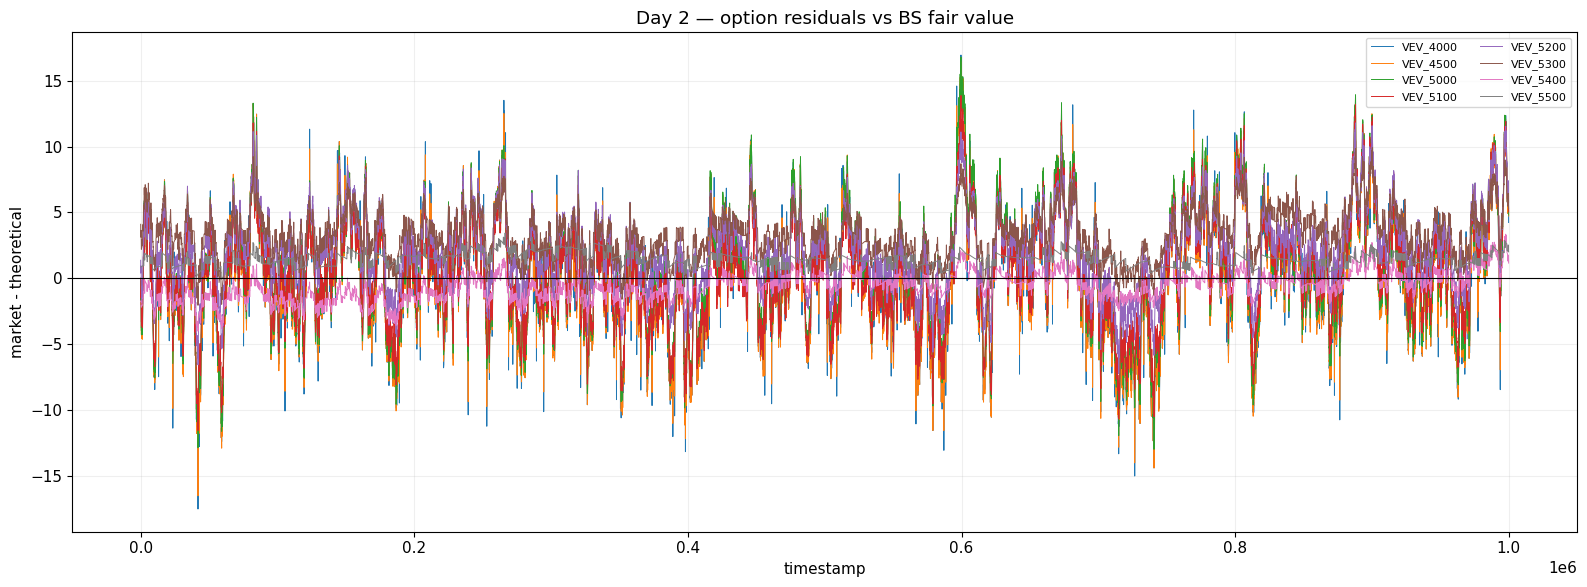

In [14]:
def option_residual_surface(day: int, sigma_guess: float = 0.215, fair_span: int = 100):
    d = prices[prices["day"] == day].copy().sort_values(["timestamp", "product"])
    ve = d[d["product"] == "VELVETFRUIT_EXTRACT"].copy()
    ve["fair"] = ve["mid_price"].ewm(span=fair_span, adjust=False).mean()
    fair_by_time = ve.groupby("timestamp")["fair"].last()

    series = {}
    for sym, K in STRIKES.items():
        opt = d[d["product"] == sym].copy()
        tmp = opt[["timestamp", "mid_price"]].copy()
        tmp["S"] = tmp["timestamp"].map(fair_by_time)
        tmp["T"] = tmp["timestamp"].apply(tte_years)
        tmp["theo"] = tmp.apply(lambda r: bs_call(r["S"], K, r["T"], sigma_guess) if pd.notna(r["S"]) else np.nan, axis=1)
        tmp["residual"] = tmp["mid_price"] - tmp["theo"]
        series[sym] = tmp.set_index("timestamp")["residual"]
    return pd.DataFrame(series)

res_day2 = option_residual_surface(2)
fig, ax = plt.subplots(figsize=(16, 6))
for sym in ["VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300", "VEV_5400", "VEV_5500"]:
    ax.plot(res_day2.index, res_day2[sym], lw=0.7, label=sym)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Day 2 — option residuals vs BS fair value")
ax.set_xlabel("timestamp")
ax.set_ylabel("market - theoretical")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


## 12. Strike-selection diagnostics

Before a trading algorithm is written, it helps to answer:
- which strikes have the best spread after model cost,
- which strikes are too noisy,
- which ones are nearly pure premium,
- which ones are worth using only for signal and not for execution.

That is a more realistic filter than “trade every voucher.”


In [15]:
def strike_diagnostics(day: int = 2, sigma_guess: float = 0.215, fair_span: int = 100) -> pd.DataFrame:
    d = prices[prices["day"] == day].copy()
    ve = d[d["product"] == "VELVETFRUIT_EXTRACT"].copy().sort_values("timestamp")
    ve["fair"] = ve["mid_price"].ewm(span=fair_span, adjust=False).mean()
    fair_by_time = ve.groupby("timestamp")["fair"].last()

    rows = []
    for sym, K in STRIKES.items():
        opt = d[d["product"] == sym].copy()
        opt["S"] = opt["timestamp"].map(fair_by_time)
        opt["T"] = opt["timestamp"].apply(tte_years)
        opt["theo"] = opt.apply(lambda r: bs_call(r["S"], K, r["T"], sigma_guess) if pd.notna(r["S"]) else np.nan, axis=1)
        opt["delta"] = opt.apply(lambda r: bs_delta(r["S"], K, r["T"], sigma_guess) if pd.notna(r["S"]) else np.nan, axis=1)
        opt["edge"] = opt["mid_price"] - opt["theo"]
        rows.append({
            "symbol": sym,
            "K": K,
            "mean_mid": opt["mid_price"].mean(),
            "mean_theo": opt["theo"].mean(),
            "mean_edge": opt["edge"].mean(),
            "median_delta": opt["delta"].median(),
            "avg_spread": (opt["ask_price_1"] - opt["bid_price_1"]).mean(),
            "trade_count": int((trades["symbol"] == sym).sum()),
        })
    return pd.DataFrame(rows).sort_values("K")

diag = strike_diagnostics(2)
display(diag.round(4))


,symbol,K,mean_mid,mean_theo,mean_edge,median_delta,avg_spread,trade_count
0,VEV_4000,4000,1255.3974,1255.2770,0.1203,1.0000,20.9005,464
1,VEV_4500,4500,755.4018,755.2770,0.1248,1.0000,15.9609,1
2,VEV_5000,5000,258.5447,257.8378,0.7069,0.9590,6.1200,1
3,VEV_5100,5100,167.3254,166.8533,0.4721,0.8572,4.3107,1
4,VEV_5200,5200,94.0470,91.8621,2.1849,0.6537,2.8605,18
5,VEV_5300,5300,44.4781,41.0575,3.4206,0.3971,2.0510,121
6,VEV_5400,5400,13.7343,14.3674,-0.6331,0.1827,1.3282,225
7,VEV_5500,5500,5.2942,3.8516,1.4427,0.0599,1.1159,267
8,VEV_6000,6000,0.5000,0.0001,0.4999,0.0000,1.0000,284
9,VEV_6500,6500,0.5000,0.0000,0.5000,0.0000,1.0000,284


## 13. Trade direction and aggressiveness

If the trade data includes buyer/seller IDs, inspect whether the market is being pushed by repeated participants or whether it is mostly anonymous flow.

For a strategy, this matters because:
- if a strike is consistently bought aggressively, it may be expensive,
- if it is consistently offered, it may be cheap,
- if one product is routinely picked off, symmetric quoting can lose money.


In [16]:
if {"buyer", "seller"}.issubset(trades.columns):
    for sym in PRODUCTS:
        td = trades[trades["symbol"] == sym].copy()
        if td.empty:
            continue
        td["is_buy_anon"] = td["buyer"].eq("") | td["buyer"].isna()
        td["is_sell_anon"] = td["seller"].eq("") | td["seller"].isna()
        print(f"{sym}: trades={len(td)}, anonymous buyer share={td['is_buy_anon'].mean():.2%}, anonymous seller share={td['is_sell_anon'].mean():.2%}")


HYDROGEL_PACK: trades=1010, anonymous buyer share=100.00%, anonymous seller share=100.00%
VELVETFRUIT_EXTRACT: trades=1372, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_4000: trades=464, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_4500: trades=1, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5000: trades=1, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5100: trades=1, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5200: trades=18, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5300: trades=121, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5400: trades=225, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_5500: trades=267, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_6000: trades=284, anonymous buyer share=100.00%, anonymous seller share=100.00%
VEV_6500: trades=284, anonymous buyer share=100.00%, anonymous se

## 13.5 Trade Flow Toxicity & Adverse Selection Analysis

If a trading algorithm is continuously losing to the market after execution, it is likely being **picked off by informed (toxic) flow**. This section analyzes trade logs to measure the **Mark-to-Market (MtM) decay** immediately after trades, quantifying adverse selection and the probability of informed trading (PIN).

For each executed trade, we measure:
- The mid-price at execution time $t=0$
- The mid-price $k$ ticks later
- The sign of the drift: if drift is negative after a buy, we were picked off (informed seller). If positive after a sell, we were picked off (informed buyer).

A persistent adverse drift indicates our fills are being adversely selected by the market.

In [17]:
def analyze_adverse_selection(trades_df: pd.DataFrame, prices_df: pd.DataFrame, target: str = "VELVETFRUIT_EXTRACT", horizon: int = 5) -> dict:
    """
    Analyze MtM decay after trades. 
    Returns: dict with statistics on adverse selection by trade direction.
    """
    # Build price lookup by global_time
    p_lookup = prices_df[prices_df['product'] == target].set_index('global_time')['mid_price'].to_dict()
    
    # Trades initiated by non-SUBMISSION (i.e., other market participants)
    tr = trades_df[trades_df['symbol'] == target].copy()
    
    if tr.empty:
        return {"error": f"No trades for {target}"}
    
    # Assume: buyer != 'SUBMISSION' or empty → someone else bought (we probably sold)
    # seller != 'SUBMISSION' or empty → someone else sold (we probably bought)
    
    results = {"buy_drifts": [], "sell_drifts": [], "buy_count": 0, "sell_count": 0}
    
    for _, row in tr.iterrows():
        t0 = row.get('global_time', None)
        if pd.isna(t0):
            continue
        
        t0 = int(t0)
        px_0 = p_lookup.get(t0, None)
        if px_0 is None:
            continue
        
        # Lookahead price
        px_future = None
        for offset in range(1, horizon + 1):
            px_future = p_lookup.get(t0 + offset, None)
            if px_future is not None:
                break
        
        if px_future is None:
            continue
        
        drift = px_future - px_0
        
        # Classify trade direction based on buyer/seller fields
        buyer_str = str(row.get('buyer', '')).strip()
        seller_str = str(row.get('seller', '')).strip()
        
        # If buyer is not 'SUBMISSION' (informed), classify as "sell" (we were on ask side)
        if buyer_str and buyer_str != 'SUBMISSION':
            results["sell_drifts"].append(drift)
            results["sell_count"] += 1
        # If seller is not 'SUBMISSION' (informed), classify as "buy" (we were on bid side)
        elif seller_str and seller_str != 'SUBMISSION':
            results["buy_drifts"].append(drift)
            results["buy_count"] += 1
    
    # Compute statistics
    stats_out = {}
    if results["buy_drifts"]:
        buy_mean = np.mean(results["buy_drifts"])
        buy_std = np.std(results["buy_drifts"])
        stats_out["buy_mean_drift"] = buy_mean
        stats_out["buy_std_drift"] = buy_std
        stats_out["buy_count"] = results["buy_count"]
        stats_out["buy_adverse_pct"] = 100 * sum(1 for d in results["buy_drifts"] if d < 0) / len(results["buy_drifts"])
    
    if results["sell_drifts"]:
        sell_mean = np.mean(results["sell_drifts"])
        sell_std = np.std(results["sell_drifts"])
        stats_out["sell_mean_drift"] = sell_mean
        stats_out["sell_std_drift"] = sell_std
        stats_out["sell_count"] = results["sell_count"]
        stats_out["sell_adverse_pct"] = 100 * sum(1 for d in results["sell_drifts"] if d > 0) / len(results["sell_drifts"])
    
    return stats_out

# Analyze adverse selection for key products
for prod in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    result = analyze_adverse_selection(trades, prices, target=prod, horizon=10)
    if "error" not in result:
        print(f"\n{prod} — Adverse Selection Analysis ({10} tick horizon):")
        print(f"  BUY side:  {result.get('buy_count', 0):3d} trades | "
              f"drift: {result.get('buy_mean_drift', np.nan):+.3f} ± {result.get('buy_std_drift', np.nan):.3f} | "
              f"adverse: {result.get('buy_adverse_pct', 0):.1f}%")
        print(f"  SELL side: {result.get('sell_count', 0):3d} trades | "
              f"drift: {result.get('sell_mean_drift', np.nan):+.3f} ± {result.get('sell_std_drift', np.nan):.3f} | "
              f"adverse: {result.get('sell_adverse_pct', 0):.1f}%")
        
        # Interpretation
        buy_adv = result.get('buy_adverse_pct', 0)
        sell_adv = result.get('sell_adverse_pct', 0)
        if buy_adv > 60:
            print(f"  ⚠️  Buy side is heavily picked off ({buy_adv:.0f}% of buys move against us)")
        if sell_adv > 60:
            print(f"  ⚠️  Sell side is heavily picked off ({sell_adv:.0f}% of sells move against us)")


HYDROGEL_PACK — Adverse Selection Analysis (10 tick horizon):
  BUY side:    0 trades | drift: +nan ± nan | adverse: 0.0%
  SELL side:   0 trades | drift: +nan ± nan | adverse: 0.0%

VELVETFRUIT_EXTRACT — Adverse Selection Analysis (10 tick horizon):
  BUY side:    0 trades | drift: +nan ± nan | adverse: 0.0%
  SELL side:   0 trades | drift: +nan ± nan | adverse: 0.0%


## 13.6 Volatility Surface & The Options Smile (Rigorous Treatment)

Options cannot be evaluated linearly. We must construct a rigorous **Implied Volatility ($\sigma_{IV}$) surface** across strikes and time.

By inverting the Black-Scholes formula on market-quoted option prices, we recover the market's perceived volatility at each strike. A non-flat smile (i.e., IV varying with strike) reveals market expectations about tail risk, skewness, and informedness.

The smile typically exhibits:
- **Volatility skew**: OTM puts trade at higher IV than ATM; OTM calls trade at lower IV (risk-reversal).
- **Smile curvature**: ATM strikes trade at lower IV than far OTM/ITM (U-shaped smile).
- **Strike clustering**: Certain strikes see heavy clustering of large trades, indicating their market importance.

This section constructs the IV surface and identifies mispricings relative to a smooth parametric model.

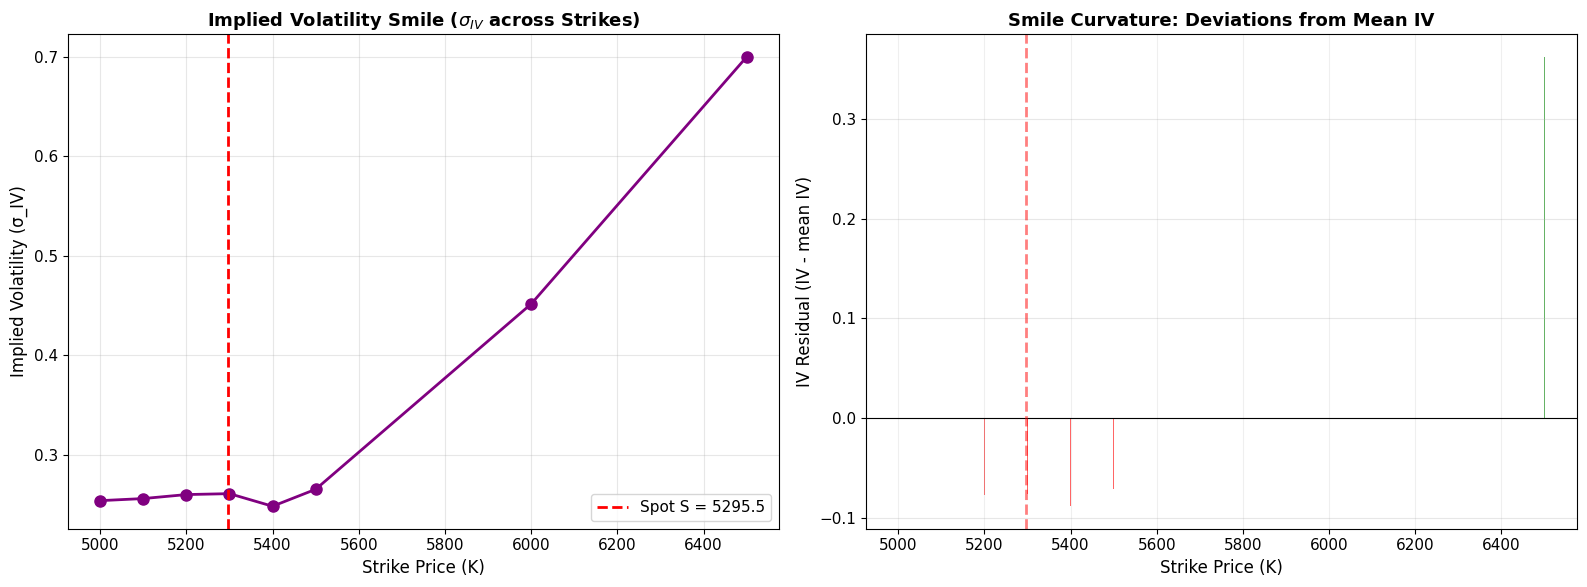


Volatility Surface @ global_time=2999900:
  Spot (VELVETFRUIT_EXTRACT): 5295.500
  Days to expiry: 3.00
  Mean IV: 0.3372
  IV range: [0.2485, 0.6998]
  IV std dev: 0.1511

  Strike details:
    K= 5000  IV=0.2541  Moneyness=0.944  Delta≈0.981
    K= 5100  IV=0.2562  Moneyness=0.963  Delta≈0.913
    K= 5200  IV=0.2602  Moneyness=0.982  Delta≈0.744
    K= 5300  IV=0.2612  Moneyness=1.001  Delta≈0.494
    K= 5400  IV=0.2485  Moneyness=1.020  Delta≈0.240
    K= 5500  IV=0.2655  Moneyness=1.039  Delta≈0.098
    K= 6000  IV=0.4517  Moneyness=1.133  Delta≈0.006
    K= 6500  IV=0.6998  Moneyness=1.227  Delta≈0.004


In [18]:
# Reconstruct the implied volatility surface at a recent snapshot
# Use the last trading timestamp to extract S, all option prices, and compute IVs

recent_timestamp = prices["global_time"].max()
snap = prices[prices["global_time"] == recent_timestamp].copy()

if not snap.empty:
    # Extract spot price
    spot_rows = snap[snap["product"] == "VELVETFRUIT_EXTRACT"]
    if not spot_rows.empty:
        S_val = float(spot_rows.iloc[0]["mid_price"])
        
        # Extract option prices and compute IVs
        vols_dict = {}
        days_passed = (recent_timestamp // TICKS_PER_DAY)
        
        for sym, K in STRIKES.items():
            opt_rows = snap[snap["product"] == sym]
            if opt_rows.empty:
                continue
            
            opt_price = float(opt_rows.iloc[0]["mid_price"])
            
            # Time to expiry (in years)
            T = (TTE_START_DAYS - days_passed) / TRADING_DAYS
            T = max(T, 0.01)  # Floor to avoid zero or negative
            
            # Compute implied vol via BS inversion
            iv = implied_vol_from_price(opt_price, S_val, K, T)
            if iv is not None:
                vols_dict[K] = iv
        
        if vols_dict:
            strikes_sorted = sorted(vols_dict.keys())
            iv_values = [vols_dict[k] for k in strikes_sorted]
            
            # Plot the IV smile
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            
            # Panel 1: IV curve
            ax1.plot(strikes_sorted, iv_values, marker='o', linestyle='-', color='purple', lw=2, markersize=8)
            ax1.axvline(x=S_val, color='r', linestyle='--', lw=2, label=f'Spot S = {S_val:.1f}')
            ax1.set_xlabel('Strike Price (K)', fontsize=12)
            ax1.set_ylabel('Implied Volatility (σ_IV)', fontsize=12)
            ax1.set_title(r'Implied Volatility Smile ($\sigma_{IV}$ across Strikes)', fontsize=13, fontweight='bold')
            ax1.grid(True, alpha=0.3)
            ax1.legend(fontsize=11)
            
            # Panel 2: Residual from mean IV (smile curvature)
            mean_iv = np.mean(iv_values)
            residuals = [iv - mean_iv for iv in iv_values]
            ax2.bar(strikes_sorted, residuals, color=['red' if r < 0 else 'green' for r in residuals], alpha=0.6)
            ax2.axhline(y=0, color='black', lw=0.8)
            ax2.axvline(x=S_val, color='r', linestyle='--', lw=2, alpha=0.5)
            ax2.set_xlabel('Strike Price (K)', fontsize=12)
            ax2.set_ylabel('IV Residual (IV - mean IV)', fontsize=12)
            ax2.set_title('Smile Curvature: Deviations from Mean IV', fontsize=13, fontweight='bold')
            ax2.grid(True, alpha=0.3, axis='y')
            
            plt.tight_layout()
            plt.show()
            
            # Print IV statistics
            print(f"\nVolatility Surface @ global_time={recent_timestamp}:")
            print(f"  Spot (VELVETFRUIT_EXTRACT): {S_val:.3f}")
            print(f"  Days to expiry: {TTE_START_DAYS - days_passed:.2f}")
            print(f"  Mean IV: {mean_iv:.4f}")
            print(f"  IV range: [{min(iv_values):.4f}, {max(iv_values):.4f}]")
            print(f"  IV std dev: {np.std(iv_values):.4f}")
            print(f"\n  Strike details:")
            for k in strikes_sorted:
                iv = vols_dict[k]
                moneyness = k / S_val
                print(f"    K={k:5d}  IV={iv:.4f}  Moneyness={moneyness:.3f}  Delta≈{bs_delta(S_val, k, T, iv):.3f}")
else:
    print("No data at the recent timestamp; cannot construct volatility surface.")

## 14. Strategy design notebook section

This is the bridge from analysis to implementation.

A practical strategy for this round usually breaks into:
1. **HYDROGEL_PACK** — a stable or slowly drifting spot-like product. Use EMA fair value, inventory skew, and conservative quoting.
2. **VELVETFRUIT_EXTRACT** — the underlying for the voucher family. Treat it as both a tradable spot and the input to option fair value.
3. **Vouchers** — compute theoretical value per strike, then trade only where the market is clearly away from fair after considering spread and hedge cost.

A good policy is:
- quote the spots only when fair value confidence is high,
- treat deep ITM and far OTM vouchers differently from ATM strikes,
- use size caps per strike,
- avoid hedging if hedge cost overwhelms edge,
- keep a cooldown after repeated fills in the same direction.


In [19]:
# Strategy skeleton: the exact live algorithm can be developed from this notebook.
# This is deliberately simple and easy to modify.

def recommend_strategy_from_stats() -> pd.DataFrame:
    rows = []
    for _, r in summary_df.iterrows():
        p = r["product"]
        if p in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
            if abs(r["lag1_acf"]) < 0.03:
                action = "EMA fair + take only on large edge"
            else:
                action = "EMA fair + inventory skew"
        else:
            if p in ["VEV_4000", "VEV_4500"]:
                action = "small long-only / wide-spread capture"
            elif p in ["VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300", "VEV_5400", "VEV_5500"]:
                action = "trade only if BS edge survives costs"
            else:
                action = "skip unless extremely favorable"
        rows.append({"product": p, "recommended_action": action})
    return pd.DataFrame(rows)

display(recommend_strategy_from_stats())


,product,recommended_action
0,HYDROGEL_PACK,EMA fair + inventory skew
1,VELVETFRUIT_EXTRACT,EMA fair + inventory skew
2,VEV_4000,small long-only / wide-spread capture
3,VEV_4500,small long-only / wide-spread capture
4,VEV_5000,trade only if BS edge survives costs
5,VEV_5100,trade only if BS edge survives costs
6,VEV_5200,trade only if BS edge survives costs
7,VEV_5300,trade only if BS edge survives costs
8,VEV_5400,trade only if BS edge survives costs
9,VEV_5500,trade only if BS edge survives costs


## 16. Conditional return and toxicity analysis

The next step is to measure *when* the market gives signal, not just whether the product is mean-reverting on average.

This section adds:
- forward-return buckets by order-book imbalance,
- forward-return buckets by spread width,
- forward-return buckets by recent trend,
- fill toxicity / adverse selection around trade prints,
- and a cleaner day-aware trade table for the CSVs.


In [20]:

import re

def load_trades_file_with_day(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df["timestamp"] = df["timestamp"].astype(int)
    m = re.search(r"day_(\d+)", path.stem)
    df["day"] = int(m.group(1)) if m else -1
    df["global_time"] = df["day"] * TICKS_PER_DAY + df["timestamp"]
    for col in ["buyer", "seller", "symbol"]:
        if col in df.columns:
            df[col] = df[col].fillna("")
    return df

trades_day = pd.concat([load_trades_file_with_day(p) for p in TRADES_FILES], ignore_index=True)
trades_day["price"] = pd.to_numeric(trades_day["price"], errors="coerce")
trades_day["quantity"] = pd.to_numeric(trades_day["quantity"], errors="coerce")

print("Loaded day-aware trades:", trades_day.shape)
display(trades_day.head())


Loaded day-aware trades: (4048, 9)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_time
0,2500,,,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0,2500
1,2900,,,VEV_5400,XIRECS,22.0,3,0,2900
2,2900,,,VEV_5500,XIRECS,8.0,3,0,2900
3,2900,,,VEV_6000,XIRECS,0.0,3,0,2900
4,2900,,,VEV_6500,XIRECS,0.0,3,0,2900


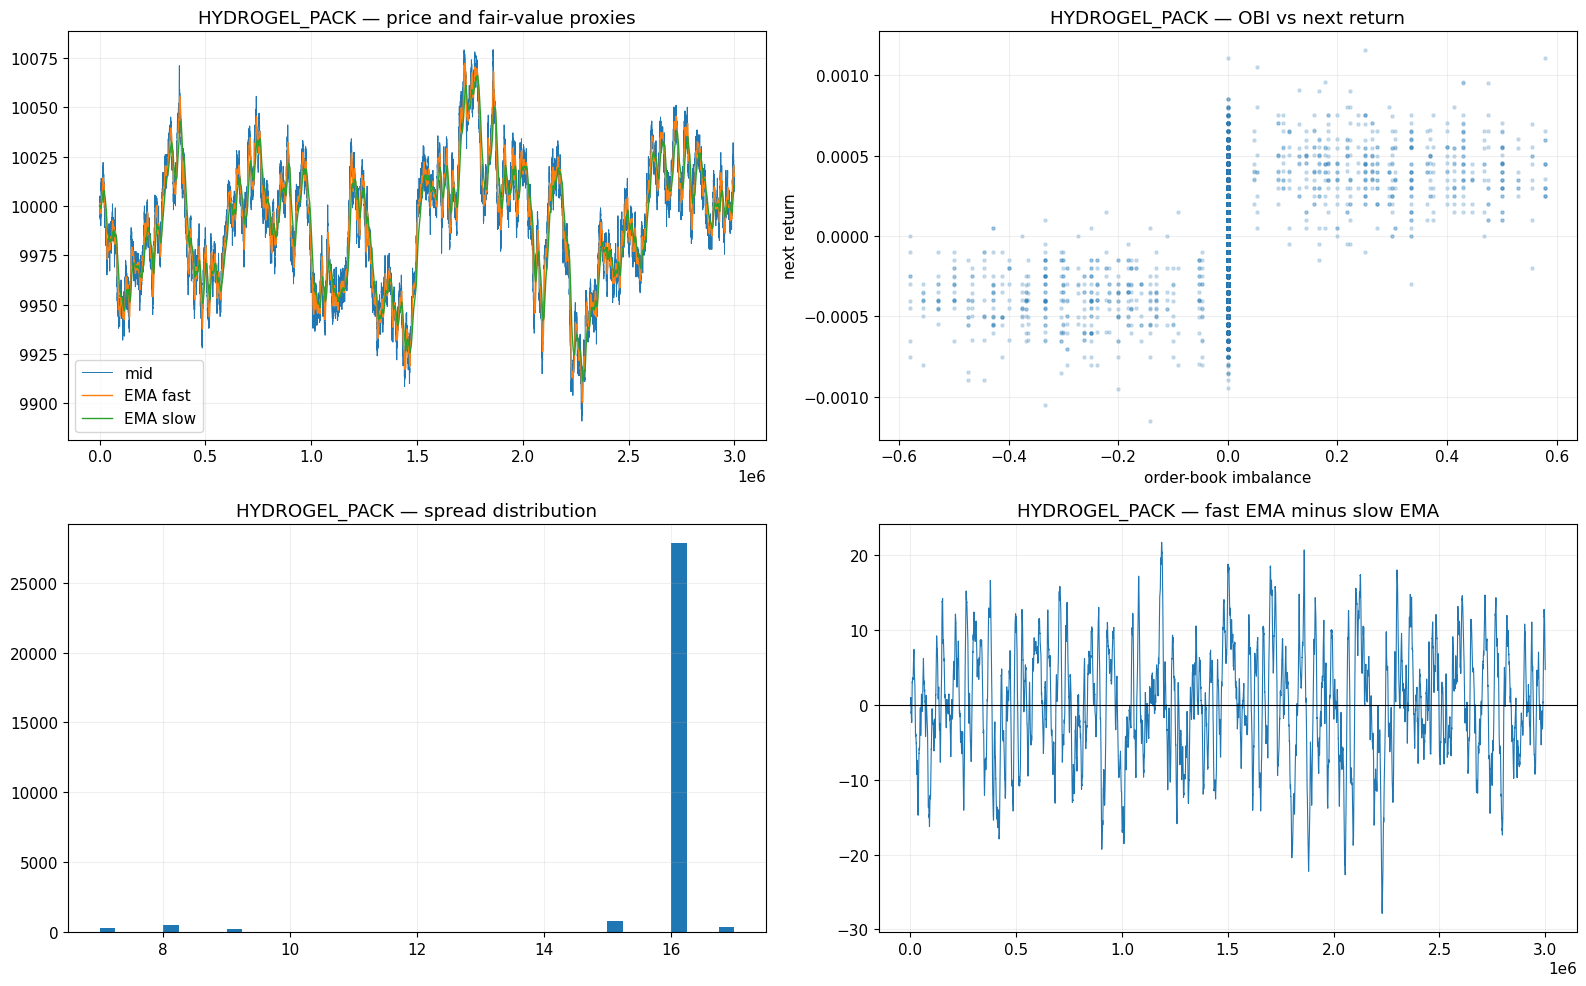


HYDROGEL_PACK conditional return table

By OBI:


,bucket,count,mean,median,std
0,very short,0,NaN,NaN,NaN
1,short,252,-0.000392,-0.000400,0.000184
2,slightly short,161,-0.000387,-0.000399,0.000183
3,neutral,29125,-0.000001,0.000000,0.000206
4,slightly long,181,0.000422,0.000449,0.000214
5,long,280,0.000405,0.000400,0.000195
6,very long,0,NaN,NaN,NaN



By spread:


,bucket,count,mean,median,std
0,tight<=4,0,NaN,NaN,NaN
1,5,0,NaN,NaN,NaN
2,6,0,NaN,NaN,NaN
3,7-8,765,0.000152,0.000300,0.000425
4,9-12,225,-0.000388,-0.000351,0.000201
5,wide>12,29009,-0.000001,0.000000,0.000205



By trend:


,bucket,count,mean,median,std
0,strong down,13746,0.000004,0.0,0.000221
1,down,808,-0.000012,0.0,0.000216
2,flat,748,-0.000011,0.0,0.000207
3,up,782,0.000010,0.0,0.000214
4,strong up,13915,-0.000003,0.0,0.000215


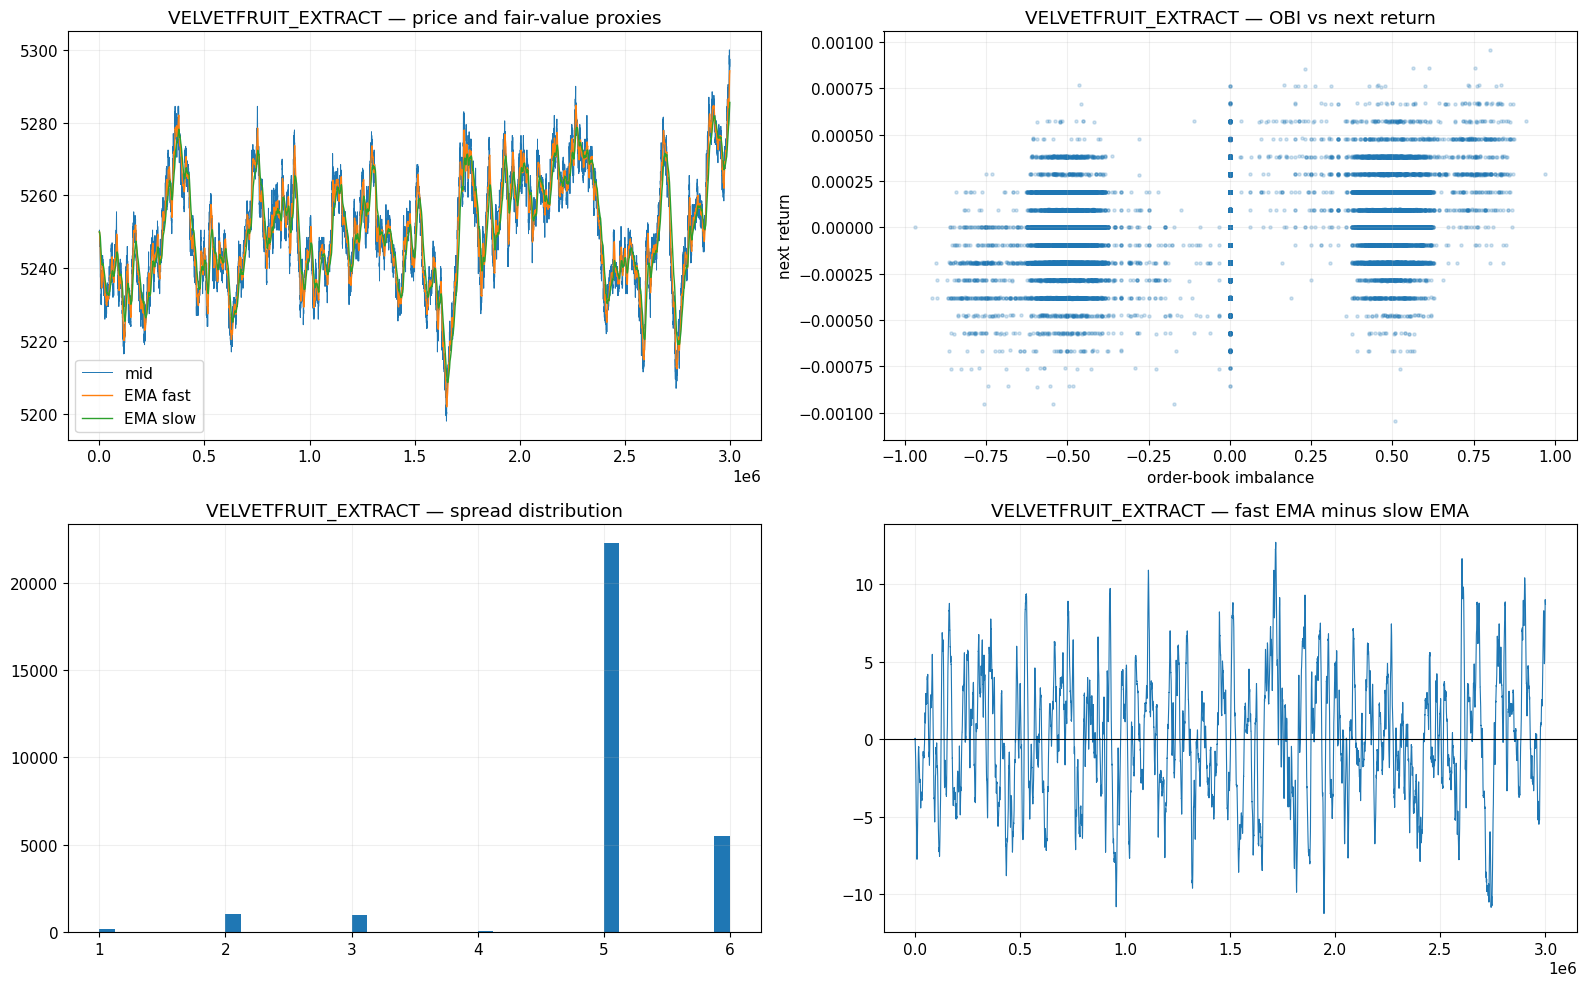


VELVETFRUIT_EXTRACT conditional return table

By OBI:


,bucket,count,mean,median,std
0,very short,780,-0.000186,-0.000190,0.000223
1,short,7871,-0.000059,0.000000,0.000201
2,slightly short,82,-0.000233,-0.000284,0.000234
3,neutral,12458,-0.000006,0.000000,0.000200
4,slightly long,101,0.000326,0.000380,0.000238
5,long,7955,0.000062,0.000000,0.000207
6,very long,752,0.000247,0.000285,0.000236



By spread:


,bucket,count,mean,median,std
0,tight<=4,2266,0.000047,0.000095,0.000336
1,5,22258,-0.000004,0.000000,0.000203
2,6,5475,-0.000003,0.000000,0.000198
3,7-8,0,NaN,NaN,NaN
4,9-12,0,NaN,NaN,NaN
5,wide>12,0,NaN,NaN,NaN



By trend:


,bucket,count,mean,median,std
0,strong down,12750,0.000002,0.0,0.000218
1,down,1386,-0.000005,0.0,0.000214
2,flat,1427,0.000005,0.0,0.000211
3,up,1292,0.000004,0.0,0.000215
4,strong up,13144,-0.000001,0.0,0.000214


In [21]:

def forward_return(df: pd.DataFrame, horizon: int = 1, price_col: str = "mid_price") -> pd.Series:
    return df[price_col].shift(-horizon) / df[price_col] - 1.0

def add_common_signals(df: pd.DataFrame, ema_span: int = 50) -> pd.DataFrame:
    out = df.copy()
    out["ema_fast"] = out["mid_price"].ewm(span=ema_span, adjust=False).mean()
    out["ema_slow"] = out["mid_price"].ewm(span=max(ema_span * 4, 200), adjust=False).mean()
    out["trend"] = out["ema_fast"] - out["ema_slow"]
    out["obi"] = (
        out["bid_volume_1"].fillna(0) - out["ask_volume_1"].fillna(0)
    ) / (out["bid_volume_1"].fillna(0) + out["ask_volume_1"].fillna(0) + 1e-9)
    out["spread"] = out["ask_price_1"] - out["bid_price_1"]
    out["spread_bps"] = out["spread"] / out["mid_price"] * 10_000
    return out

def bucket_stats(
    df: pd.DataFrame,
    signal_col: str,
    ret_col: str,
    bins: List[float],
    labels: Optional[List[str]] = None,
) -> pd.DataFrame:
    x = df[[signal_col, ret_col]].dropna().copy()
    x["bucket"] = pd.cut(x[signal_col], bins=bins, labels=labels, include_lowest=True)
    return (
        x.groupby("bucket", observed=False)[ret_col]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )

def analyze_regime(product: str, horizons: List[int] = [1, 5, 10]) -> None:
    x = prices[prices["product"] == product].sort_values(["day", "timestamp"]).copy()
    x = add_common_signals(x, ema_span=50)
    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    ax[0,0].plot(x["global_time"], x["mid_price"], lw=0.7, label="mid")
    ax[0,0].plot(x["global_time"], x["ema_fast"], lw=1.0, label="EMA fast")
    ax[0,0].plot(x["global_time"], x["ema_slow"], lw=1.0, label="EMA slow")
    ax[0,0].set_title(f"{product} — price and fair-value proxies")
    ax[0,0].legend()

    ax[0,1].scatter(x["obi"], x["mid_price"].pct_change().shift(-1), s=5, alpha=0.2)
    ax[0,1].set_title(f"{product} — OBI vs next return")
    ax[0,1].set_xlabel("order-book imbalance")
    ax[0,1].set_ylabel("next return")

    ax[1,0].hist(x["spread"].dropna(), bins=40)
    ax[1,0].set_title(f"{product} — spread distribution")

    ax[1,1].plot(x["global_time"], x["trend"], lw=0.8)
    ax[1,1].axhline(0, color="black", lw=0.8)
    ax[1,1].set_title(f"{product} — fast EMA minus slow EMA")
    plt.tight_layout()
    plt.show()

    print(f"\n{product} conditional return table")
    tmp = x.copy()
    tmp["ret_1"] = forward_return(tmp, 1)
    tmp["ret_5"] = forward_return(tmp, 5)
    tmp["ret_10"] = forward_return(tmp, 10)

    for h in horizons:
        tmp[f"ret_{h}"] = forward_return(tmp, h)

    # OBI buckets
    obi_bins = [-10, -0.6, -0.25, -0.1, 0.1, 0.25, 0.6, 10]
    obi_labels = ["very short", "short", "slightly short", "neutral", "slightly long", "long", "very long"]
    print("\nBy OBI:")
    display(bucket_stats(tmp, "obi", "ret_1", obi_bins, obi_labels).round(6))

    print("\nBy spread:")
    spread_bins = [-1, 4, 5, 6, 8, 12, 100]
    spread_labels = ["tight<=4", "5", "6", "7-8", "9-12", "wide>12"]
    display(bucket_stats(tmp, "spread", "ret_1", spread_bins, spread_labels).round(6))

    print("\nBy trend:")
    trend_bins = [-np.inf, -0.75, -0.25, 0.25, 0.75, np.inf]
    trend_labels = ["strong down", "down", "flat", "up", "strong up"]
    display(bucket_stats(tmp, "trend", "ret_1", trend_bins, trend_labels).round(6))

for p in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    analyze_regime(p)


In [22]:

def trade_toxicity(trades_df: pd.DataFrame, prices_df: pd.DataFrame, product: str, horizons: List[int] = [1, 5, 10, 20]) -> pd.DataFrame:
    """
    Estimate post-trade drift using the quote snapshot at the trade timestamp.
    We use the closest price snapshot from the same day and timestamp if available.
    If there is no exact match, the nearest earlier snapshot on that day is used.
    """
    p = prices_df[prices_df["product"] == product].copy().sort_values(["day", "timestamp"])
    t = trades_df[trades_df["symbol"] == product].copy()
    if t.empty:
        return pd.DataFrame()

    # Determine aggressor side if buyer/seller information is available.
    # Otherwise infer side from trade price relative to mid at the matching snapshot.
    p_small = p[["day", "timestamp", "global_time", "mid_price", "bid_price_1", "ask_price_1"]].copy()
    t = t.sort_values("global_time").copy()
    t = pd.merge_asof(
        t,
        p_small.sort_values("global_time"),
        on="global_time",
        direction="backward",
        suffixes=("", "_px")
    )
    t["side"] = np.where(
        (t["buyer"].fillna("") != "") | (t["seller"].fillna("") != ""),
        np.where((t["buyer"].fillna("") == "SUBMISSION"), "buy", np.where((t["seller"].fillna("") == "SUBMISSION"), "sell", "unknown")),
        np.where(t["price"] >= t["mid_price"], "buy", "sell")
    )

    future = p[["day", "timestamp", "global_time", "mid_price"]].copy()
    rows = []
    for h in horizons:
        tmp = t.copy()
        tmp["target_time"] = tmp["global_time"] + h * (TICKS_PER_DAY // 10000)  # analysis horizon in tick-like units
        # Use merge_asof to find the next available snapshot at/after target_time.
        fut = future.rename(columns={"global_time": "future_time", "mid_price": f"mid_fut_{h}"})
        tmp = pd.merge_asof(
            tmp.sort_values("target_time"),
            fut.sort_values("future_time"),
            left_on="target_time",
            right_on="future_time",
            direction="forward"
        )
        tmp[f"drift_{h}"] = (tmp[f"mid_fut_{h}"] - tmp["mid_price"]) / tmp["mid_price"]
        tmp[f"adverse_{h}"] = np.where(tmp["side"] == "buy", -tmp[f"drift_{h}"], tmp[f"drift_{h}"])
        rows.append({
            "horizon": h,
            "n": len(tmp),
            "buy_side_mean": tmp.loc[tmp["side"] == "buy", f"adverse_{h}"].mean(),
            "sell_side_mean": tmp.loc[tmp["side"] == "sell", f"adverse_{h}"].mean(),
            "overall_mean": tmp[f"adverse_{h}"].mean(),
            "overall_median": tmp[f"adverse_{h}"].median(),
        })

    return pd.DataFrame(rows)

for p in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]:
    print(f"\nToxicity estimates for {p}")
    display(trade_toxicity(trades_day, prices, p).round(6))



Toxicity estimates for HYDROGEL_PACK


,horizon,n,buy_side_mean,sell_side_mean,overall_mean,overall_median
0,1,1010,0.000008,0.000003,0.000005,0.0
1,5,1010,0.000015,-0.000003,0.000007,0.0
2,10,1010,-0.000000,-0.000002,-0.000001,0.0
3,20,1010,0.000017,0.000030,0.000023,0.0



Toxicity estimates for VELVETFRUIT_EXTRACT


,horizon,n,buy_side_mean,sell_side_mean,overall_mean,overall_median
0,1,1372,-0.000079,-0.000023,-0.000055,0.000000
1,5,1372,-0.000089,0.000002,-0.000049,0.000000
2,10,1372,-0.000075,-0.000030,-0.000056,-0.000095
3,20,1372,-0.000103,-0.000010,-0.000063,-0.000095


## 17. Smoothed volatility smile and moneyness structure

The next question is whether the voucher structure is stable across time, or whether one strike is only cheap/rich in some parts of the day.

This section checks:
- implied vol vs log-moneyness,
- smile stability across timestamps,
- and whether the anomaly is persistent enough to trade.


In [23]:

def implied_vol(mkt: float, S: float, K: float, T: float) -> Optional[float]:
    intrinsic = max(S - K, 0.0)
    if pd.isna(mkt) or pd.isna(S) or T <= 1e-12 or mkt <= intrinsic + 1e-9:
        return np.nan
    lo, hi = 0.01, 1.50
    try:
        if bs_call(S, K, T, lo) > mkt or bs_call(S, K, T, hi) < mkt:
            return np.nan
    except Exception:
        return np.nan
    for _ in range(50):
        mid = (lo + hi) / 2.0
        v = bs_call(S, K, T, mid)
        if abs(v - mkt) < 1e-4:
            return mid
        if v < mkt:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0


(300000, 32)


,day,timestamp,product,S,iv,residual,log_moneyness
0,0,0,VEV_4000,5250.000000,NaN,0.000000,0.271934
1,0,100,VEV_4000,5250.009901,0.715213,0.490099,0.271936
2,0,200,VEV_4000,5250.019606,0.713780,0.480394,0.271937
3,0,300,VEV_4000,5250.029119,0.712348,0.470881,0.271939
4,0,400,VEV_4000,5250.038443,0.710938,0.461557,0.271941


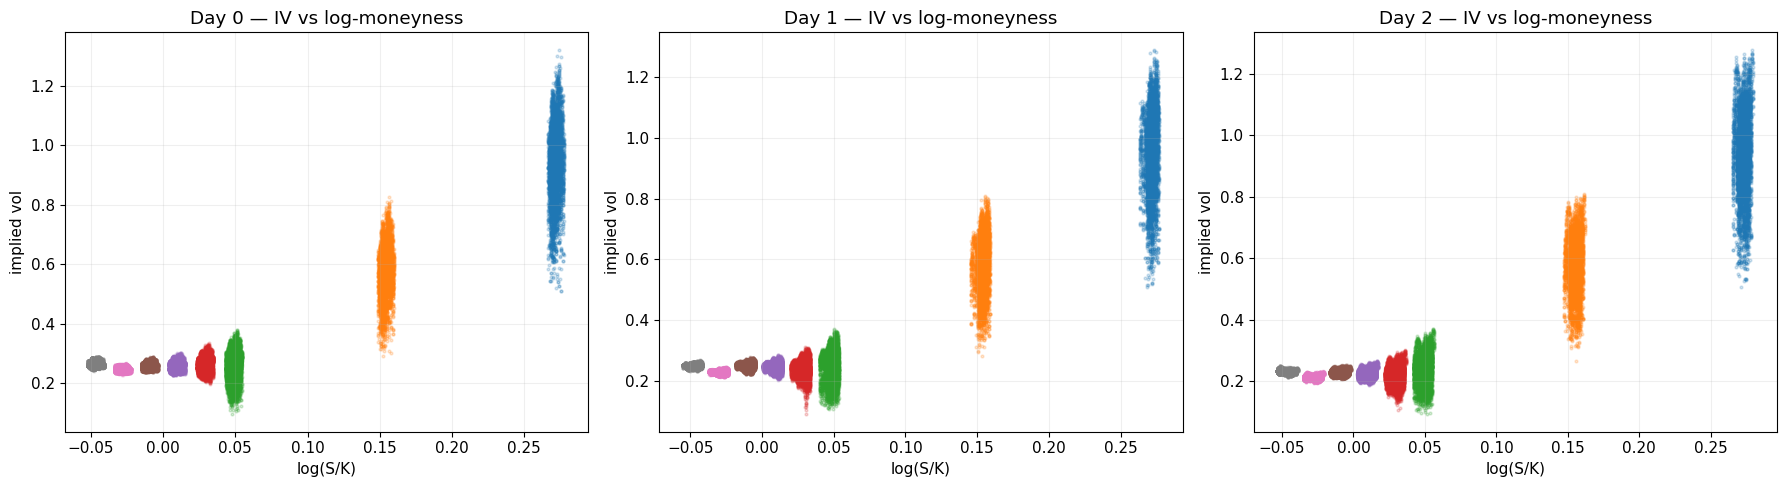

C:\Users\amans\AppData\Local\Temp\ipykernel_29104\1804583386.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["time_bucket", "product"])["iv"]


product,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
time_bucket,,,,,,,,,,
"(-0.001, 199980.0]",0.8860,0.5401,0.2405,0.2362,0.2381,0.2386,0.2276,0.2472,0.3764,0.5690
"(199980.0, 399960.0]",0.9139,0.5602,0.2493,0.2389,0.2419,0.2441,0.2295,0.2498,0.3795,0.5767
"(399960.0, 599940.0]",0.9166,0.5554,0.2415,0.2346,0.2439,0.2465,0.2297,0.2478,0.3960,0.5972
"(599940.0, 799920.0]",0.9716,0.5919,0.2591,0.2433,0.2451,0.2510,0.2290,0.2509,0.4022,0.6083
"(799920.0, 999900.0]",1.0229,0.6280,0.2712,0.2489,0.2483,0.2533,0.2310,0.2514,0.4059,0.6166


In [24]:

def add_option_features(day: int, sigma_guess: float = 0.215, fair_span: int = 100) -> pd.DataFrame:
    d = prices[prices["day"] == day].copy().sort_values(["timestamp", "product"])
    ve = d[d["product"] == "VELVETFRUIT_EXTRACT"].copy().sort_values("timestamp")
    ve["fair"] = ve["mid_price"].ewm(span=fair_span, adjust=False).mean()
    fair_by_time = ve.groupby("timestamp")["fair"].last()

    frames = []
    for sym, K in STRIKES.items():
        opt = d[d["product"] == sym].copy()
        opt["S"] = opt["timestamp"].map(fair_by_time)
        opt["T"] = opt["timestamp"].apply(tte_years)
        opt["theo"] = opt.apply(lambda r: bs_call(r["S"], K, r["T"], sigma_guess) if pd.notna(r["S"]) else np.nan, axis=1)
        opt["delta"] = opt.apply(lambda r: bs_delta(r["S"], K, r["T"], sigma_guess) if pd.notna(r["S"]) else np.nan, axis=1)
        opt["iv"] = opt.apply(lambda r: implied_vol(r["mid_price"], r["S"], K, r["T"]) if pd.notna(r["S"]) else np.nan, axis=1)
        opt["residual"] = opt["mid_price"] - opt["theo"]
        opt["log_moneyness"] = np.log(opt["S"] / K)
        opt["day"] = day
        frames.append(opt)
    return pd.concat(frames, ignore_index=True)

smile_features = pd.concat([add_option_features(d) for d in sorted(prices["day"].unique())], ignore_index=True)
print(smile_features.shape)
display(smile_features[["day", "timestamp", "product", "S", "iv", "residual", "log_moneyness"]].head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, day in zip(axes, sorted(prices["day"].unique())):
    x = smile_features[smile_features["day"] == day].dropna(subset=["iv", "log_moneyness"])
    for sym in ["VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300", "VEV_5400", "VEV_5500"]:
        y = x[x["product"] == sym]
        ax.scatter(y["log_moneyness"], y["iv"], s=4, alpha=0.2)
    ax.set_title(f"Day {day} — IV vs log-moneyness")
    ax.set_xlabel("log(S/K)")
    ax.set_ylabel("implied vol")
plt.tight_layout()
plt.show()

# Time-slice smile stability
time_bins = pd.qcut(smile_features["timestamp"], q=5, duplicates="drop")
smile_features["time_bucket"] = time_bins
pivot = (
    smile_features.dropna(subset=["iv"])
    .groupby(["time_bucket", "product"])["iv"]
    .median()
    .unstack("product")
)
display(pivot.round(4))


## 18. Conviction-to-size mapping

The hints say not to treat every signal the same. Size should scale with conviction.

A good starting rule is:
- residual just above threshold → small size
- residual clearly above threshold → medium size
- residual extreme and persistent → larger size
- signal weak or noisy → skip

This section turns that into a reusable sizing template.


In [26]:

def conviction_to_size(edge: float, threshold: float, cap: int, power: float = 1.25) -> int:
    """
    Map a positive edge into a size. Small edges get tiny size; large edges grow nonlinearly.
    """
    if pd.isna(edge) or edge <= threshold:
        return 0
    scale = (edge / threshold) - 1.0
    size = int(round(cap * min(1.0, scale ** power)))
    return max(1, min(cap, size))

example_edges = pd.DataFrame({
    "edge": [0.2, 0.5, 1.0, 2.0, 4.0, 8.0],
})
example_edges["size_1"] = example_edges["edge"].apply(lambda e: conviction_to_size(e, threshold=0.5, cap=20))
example_edges["size_2"] = example_edges["edge"].apply(lambda e: conviction_to_size(e, threshold=1.0, cap=40))
display(example_edges)

# Use this to transform option residuals into position targets:
residual_summary = (
    smile_features.dropna(subset=["residual"])
    .groupby("product")["residual"]
    .agg(["mean", "median", "std", lambda s: s.abs().mean()])
    .rename(columns={"<lambda_0>": "mean_abs"})
)
display(residual_summary.round(4))


,edge,size_1,size_2
0,0.2,0,0
1,0.5,0,0
2,1.0,20,0
3,2.0,20,40
4,4.0,20,40
5,8.0,20,40


,mean,median,std,mean_abs
product,,,,
VEV_4000,0.0729,0.0249,4.6067,3.6931
VEV_4500,0.0727,0.0361,4.5792,3.6750
VEV_5000,2.1972,2.0616,4.4574,3.9536
VEV_5100,4.4156,4.3508,5.0901,5.4626
VEV_5200,7.0933,7.3115,4.7796,7.3323
VEV_5300,7.7797,8.1414,3.8607,7.7878
VEV_5400,2.5497,2.5352,2.7978,3.0760
VEV_5500,3.1236,3.1587,1.5132,3.1236
VEV_6000,0.4999,0.5000,0.0001,0.4999


## 19. Neighboring-strike relative value

Single-strike mispricing is useful, but neighboring-strike spreads are often cleaner.

This section compares adjacent vouchers directly:
- market spread,
- theoretical BS spread,
- and residual spread.

That helps decide whether to trade outright options or relative-value pairs.


In [25]:

def adjacent_strike_analysis(day: Optional[int] = None, sigma_guess: float = 0.215, fair_span: int = 100) -> pd.DataFrame:
    if day is None:
        d = prices.copy().sort_values(["day", "timestamp", "product"])
    else:
        d = prices[prices["day"] == day].copy().sort_values(["day", "timestamp", "product"])

    out_rows = []
    for dd in sorted(d["day"].unique()):
        day_df = d[d["day"] == dd].copy()
        ve = day_df[day_df["product"] == "VELVETFRUIT_EXTRACT"].copy().sort_values("timestamp")
        ve["fair"] = ve["mid_price"].ewm(span=fair_span, adjust=False).mean()
        fair_by_time = ve.groupby("timestamp")["fair"].last()

        for ts in sorted(day_df["timestamp"].unique()):
            S = fair_by_time.get(ts, np.nan)
            T = tte_years(ts)
            if pd.isna(S):
                continue

            mids = {}
            theos = {}
            for sym, K in STRIKES.items():
                row = day_df[(day_df["timestamp"] == ts) & (day_df["product"] == sym)]
                if row.empty:
                    continue
                mid = float(row["mid_price"].iloc[0])
                mids[sym] = mid
                theos[sym] = bs_call(S, K, T, sigma_guess)

            # adjacent pairs
            ordered = sorted(STRIKES.items(), key=lambda kv: kv[1])
            for (s1, k1), (s2, k2) in zip(ordered[:-1], ordered[1:]):
                if s1 in mids and s2 in mids:
                    out_rows.append({
                        "day": dd,
                        "timestamp": ts,
                        "pair": f"{s1}-{s2}",
                        "k1": k1,
                        "k2": k2,
                        "market_spread": mids[s1] - mids[s2],
                        "theo_spread": theos[s1] - theos[s2],
                        "residual_spread": (mids[s1] - mids[s2]) - (theos[s1] - theos[s2]),
                    })

    return pd.DataFrame(out_rows)

adj = adjacent_strike_analysis()
display(adj.groupby("pair")[["market_spread", "theo_spread", "residual_spread"]].agg(["mean", "median", "std"]).round(4))

fig, ax = plt.subplots(figsize=(14, 6))
for pair in ["VEV_4000-VEV_4500", "VEV_5000-VEV_5100", "VEV_5200-VEV_5300", "VEV_5300-VEV_5400"]:
    x = adj[adj["pair"] == pair]
    ax.scatter(x["theo_spread"], x["market_spread"], s=5, alpha=0.25, label=pair)
ax.axline((0,0), slope=1, color="black", lw=1)
ax.set_title("Adjacent voucher spreads: market vs theoretical")
ax.set_xlabel("theoretical spread")
ax.set_ylabel("market spread")
ax.legend()
plt.show()


## 20. Strategy translation from the new analysis

The last step is to map the measurements into trading rules.

- Spots: trade only when fair value, imbalance, and spread all agree.
- Vouchers: use the smile and residual structure, then size by conviction.
- Relative value: prefer neighboring-strike spreads when the outright option signal is noisy.
- Inventory: keep a hard cap and reduce size when the signal weakens.

This is the point where the notebook becomes a live strategy builder instead of only a descriptive report.


In [27]:

strategy_rows = [
    {"product": "HYDROGEL_PACK", "analysis_to_use": "spread + OBI + trend regime", "strategy": "mean-reversion core, but widen when toxicity is high"},
    {"product": "VELVETFRUIT_EXTRACT", "analysis_to_use": "microprice + OBI + toxicity", "strategy": "selective take/make; avoid symmetric quoting when flow is toxic"},
    {"product": "VEV_4000", "analysis_to_use": "delta ~ 1, wide spread", "strategy": "small passive capture / small long if cheap"},
    {"product": "VEV_4500", "analysis_to_use": "delta ~ 1, wide spread", "strategy": "small passive capture / small long if cheap"},
    {"product": "VEV_5000", "analysis_to_use": "smile residual + cross-strike spread", "strategy": "trade only if BS edge survives costs"},
    {"product": "VEV_5100", "analysis_to_use": "smile residual + cross-strike spread", "strategy": "trade only if BS edge survives costs"},
    {"product": "VEV_5200", "analysis_to_use": "smile residual + cross-strike spread", "strategy": "likely rich; favor selling if residual remains persistent"},
    {"product": "VEV_5300", "analysis_to_use": "smile residual + cross-strike spread", "strategy": "only trade if residual is stable; otherwise skip"},
    {"product": "VEV_5400", "analysis_to_use": "moneyness + smile position", "strategy": "use as a conviction name; size with residual strength"},
    {"product": "VEV_5500", "analysis_to_use": "moneyness + smile position", "strategy": "small only; likely less clean than 5400"},
    {"product": "VEV_6000", "analysis_to_use": "deep OTM premium floor", "strategy": "skip or very tiny premium sale"},
    {"product": "VEV_6500", "analysis_to_use": "deep OTM premium floor", "strategy": "skip or very tiny premium sale"},
]
strategy_df = pd.DataFrame(strategy_rows)
display(strategy_df)


,product,analysis_to_use,strategy
0,HYDROGEL_PACK,spread + OBI + trend regime,"mean-reversion core, but widen when toxicity i..."
1,VELVETFRUIT_EXTRACT,microprice + OBI + toxicity,selective take/make; avoid symmetric quoting w...
2,VEV_4000,"delta ~ 1, wide spread",small passive capture / small long if cheap
3,VEV_4500,"delta ~ 1, wide spread",small passive capture / small long if cheap
4,VEV_5000,smile residual + cross-strike spread,trade only if BS edge survives costs
5,VEV_5100,smile residual + cross-strike spread,trade only if BS edge survives costs
6,VEV_5200,smile residual + cross-strike spread,likely rich; favor selling if residual remains...
7,VEV_5300,smile residual + cross-strike spread,only trade if residual is stable; otherwise skip
8,VEV_5400,moneyness + smile position,use as a conviction name; size with residual s...
9,VEV_5500,moneyness + smile position,small only; likely less clean than 5400


## 21. What to use next

From here, the best next step is not more generic models. It is:
- inspect one product family at a time,
- derive a fair-value series,
- compare your strategy fill prices to that fair value,
- and build a small set of executable rules that survive spread and inventory cost.

That is the main loop for turning this notebook into a trading bot.

